# TDS Trend & Forecast — LAGWRP (Los Angeles–Glendale Water Reclamation Plant)

**Objetivo do projeto:** avaliar se a salinidade (TDS) do efluente da LAGWRP aumentou ao longo de ~15 anos (2011-2026), quantificar essa tendência, construir modelos de previsão para +10/+15/+20 anos, e investigar a correlação entre TDS e dois indicadores de desempenho do tratamento biológico (Amônia e BOD).

Este notebook reúne o projeto inteiro (pré-processamento, análise exploratória, bateria de métodos, comparação final) chamando as mesmas funções dos scripts `.py` na raiz do projeto — nunca duplicando a lógica manualmente. Ver `plano_projeto_TDS.md` para o plano completo.

**Status atual: projeto completo.** `script_00` a `script_15` implementados e validados — 21 métodos de previsão, todos com validação temporal honesta; análise de estrutura da série; correlação TDS-Amônia/BOD nos três tratamentos de ND; diagnóstico de resíduos dos candidatos mais fortes; comparação qualitativa com a literatura (fontes verificadas via WebFetch, não citadas às cegas); e síntese final com três finalistas complementares recomendados (regressão bayesiana, Detrend+RF, híbrido SARIMA+Prophet). Os quatro objetivos do projeto (tendência, previsão, correlação, interpretação em contexto real) estão endereçados.

> **Rastreamento de experimentos:** as execuções dos scripts são rastreadas localmente com MLflow (sem nuvem, sem conta — ver `plano_projeto_TDS.md` §4.3 e `utils/experiment_tracking.py`). `script_01` a `script_13` (exceto `script_00`/`script_06`, que não são metodologias de previsão) abrem uma run por método (rodando `python script_0X_....py`, não as chamadas diretas de função usadas neste notebook). Para abrir o dashboard: `mlflow ui --backend-store-uri sqlite:///mlflow.db`. O `resultados_comparacao.csv` continua sendo a fonte usada pelas células abaixo e pelo artigo — o MLflow é o histórico complementar de execuções (incluindo tentativas descartadas).

## Como ler este notebook

**O problema, em linguagem simples:** a estação de tratamento de esgoto LAGWRP, em Los Angeles, descarrega água tratada (efluente) no Rio Los Angeles. Nos últimos ~15 anos, a "salinidade" dessa água — medida como TDS ([Sólidos Dissolvidos Totais](GLOSSARIO.md#tds--total-dissolved-solids-sólidos-dissolvidos-totais)) — pode ter subido. Isso importa porque sal em excesso pode prejudicar as bactérias que fazem o tratamento biológico do esgoto (ver [Nitrificação](GLOSSARIO.md#nitrificação)), e porque medidas de conservação de água em Los Angeles (usar menos água em casa) podem, sem querer, concentrar mais o esgoto que ainda entra no sistema — a mesma massa de sal, num volume menor de água.

**Pergunta de pesquisa:** o TDS do efluente da LAGWRP realmente subiu ao longo do tempo? Quanto? E dá para prever os próximos 10/15/20 anos com alguma confiança?

**Mapa do notebook:**
1. §1-2 — carregar e explorar os dados brutos.
2. §2.5, §3.e — estrutura da série e correlação TDS×Amônia/BOD (objetivo 3 do projeto).
3. §3 — bateria de 21 métodos de tendência/previsão (objetivos 1-2).
4. §4 — tabela comparativa, diagnóstico de resíduos, síntese final.
5. §5 — conclusão, limitações e o que ficou em aberto.
6. §6 — tratamento de dados mais robusto: reconstrução da vazão e matriz de sensibilidade, que revelaram que a "tendência" do TDS é mais frágil — e mais interessante (um padrão cíclico ligado a secas, não uma reta subindo) — do que a primeira leitura sugeria.

**Documentos de apoio (abra em outra aba enquanto lê):**
- [`GLOSSARIO.md`](GLOSSARIO.md) — todo termo técnico usado aqui, explicado.
- [`ESCOPO_E_LIMITACOES.md`](ESCOPO_E_LIMITACOES.md) — o que este trabalho cobre, o que ficou de fora e por quê.
- [`Artigo/DECISOES.md`](Artigo/DECISOES.md) — o registro de *por que* cada escolha metodológica foi feita (formato ADR: decisão, alternativa descartada, evidência).
- [`plano_projeto_TDS.md`](plano_projeto_TDS.md) — o plano de execução completo.

**Como ler cada seção:** antes do código, uma célula explica o que a etapa faz, por que ela é necessária, que termos técnicos aparecem, e como interpretar o resultado que vem a seguir — inclusive o que **não** dá para concluir dele.


### O que esta etapa faz
Carrega os 4 arquivos brutos do eSMR (`TDS.csv`, `Chloride.csv`, `Ammonia.csv`, `BOD.csv`) e constrói a série mensal canônica do efluente da estação — uma linha por mês, já filtrada e unificada.

### Por que é necessária
Os dados brutos têm ritmo desigual entre parâmetros (TDS/Amônia ~mensal, Cloreto bem mais frequente, BOD quase diário) e dois códigos de local (`EFF-001` até 2012, `EFF-001A` depois) para o **mesmo ponto físico** — sem esse pré-processamento não existe uma série única e comparável para nenhuma análise seguinte.

### Termos técnicos
- [eSMR](GLOSSARIO.md#esmr--electronic-self-monitoring-report) — formato dos dados brutos.
- [ND — Non-Detect](GLOSSARIO.md#nd--non-detect-não-detectado) e [MDL/ML/RL](GLOSSARIO.md#mdl-ml-rl--limites-de-detecção-e-quantificação) — como o BOD abaixo do limite de detecção é sinalizado.
- [Dado censurado à esquerda](GLOSSARIO.md#dado-censurado-à-esquerda-left-censored) e [ROS](GLOSSARIO.md#ros--regression-on-order-statistics) — como esse ND é tratado nesta etapa.

### Como interpretar o resultado abaixo
Aqui não há métrica de qualidade a julgar — um bom resultado é simplesmente "182 meses, fev/2011 a fev/2026, sem buracos". O que **não** dá para concluir ainda: nada sobre tendência ou causa — isso só vem nas seções seguintes.

### Decisões registradas
Unificar `EFF-001`/`EFF-001A` (ver [D-06](Artigo/DECISOES.md#d-06--unificar-eff-001-e-eff-001a-como-uma-única-série)), usar a série `Monthly Average (Mean)` pronta em vez de reagregar (ver [D-08](Artigo/DECISOES.md#d-08--série-canônica-monthly-average-mean-em-mgl) e [D-09](Artigo/DECISOES.md#d-09--usar-a-média-mensal-pré-calculada-em-vez-de-reagregar)), e manter três tratamentos paralelos de ND do BOD em vez de escolher um só (ver [D-16](Artigo/DECISOES.md#d-16--tratamento-dos-valores-nd-do-bod-65-da-série)).


## 1. Carregamento e pré-processamento dos dados

Os dados brutos vêm do portal eSMR (California Water Boards), exportados em 4 planilhas (`TDS.csv`, `Chloride.csv`, `Ammonia.csv`, `BOD.csv`, `sep=';' decimal=','`). `script_00_preprocessamento.py` filtra a série mensal canônica do efluente (`EFF-001`+`EFF-001A` unificados, `Calculated Method == "Monthly Average (Mean)"`, `Units == "mg/L"`).

Os valores não detectados (ND) de BOD (65% dos meses, ver `plano_projeto_TDS.md` §1.3 e `script_00b_analise_censura_bod.py`) foram tratados de **três formas em paralelo** (decisão do usuário, aprovada após apresentação dos números reais):
- **Dataset A** — ND do BOD = MDL/2 (1,5 mg/L)
- **Dataset B** — ND do BOD = 0
- **Dataset F** — ND do BOD = estimativa ROS/Helsel (2,517 mg/L, ajustada a partir da forma real da distribuição dos valores detectados — ver `script_00b`)

In [ ]:
import sys
sys.path.insert(0, '.')
from script_00_preprocessamento import construir_datasets

dataset_a, dataset_b, dataset_c, base = construir_datasets()
print(f"Dataset A (BOD ND=MDL/2):      {dataset_a.shape}")
print(f"Dataset B (BOD ND=0):          {dataset_b.shape}")
print(f"Dataset F (BOD ND=ROS/Helsel): {dataset_c.shape}")
dataset_a.head()

In [2]:
print(f"Periodo: {base['Data'].min().date()} a {base['Data'].max().date()}  ({len(base)} meses)")
print(f"Meses com BOD ND: {int(base['BOD_foi_ND'].sum())} / {int(base['BOD_foi_ND'].notna().sum())}")
print()
print("Valores ausentes por coluna (dataset A):")
print(dataset_a.isna().sum())

Periodo: 2011-02-28 a 2026-03-31  (182 meses)
Meses com BOD ND: 118 / 181

Valores ausentes por coluna (dataset A):
Data            0
TDS_mgL         0
Chloride_mgL    0
Ammonia_mgL     0
BOD_foi_ND      1
BOD_mgL         1
dtype: int64


### O que esta etapa faz
Plota as séries mensais de TDS, Cloreto, Amônia e BOD (sob os dois/três tratamentos de ND) para uma primeira inspeção visual, antes de qualquer teste formal.

### Por que é necessária
Antes de rodar qualquer estatística, vale olhar o dado bruto: existe alguma quebra visual óbvia, algum outlier evidente, algum padrão sazonal a olho nu? Isso orienta o que testar formalmente depois (§2.5, §3).

### Termos técnicos
[TDS](GLOSSARIO.md#tds--total-dissolved-solids-sólidos-dissolvidos-totais), [BOD/DBO](GLOSSARIO.md#bod--dbo--biochemical-oxygen-demand-demanda-bioquímica-de-oxigênio), [Amônia](GLOSSARIO.md#amônia-ammonia-total-as-n) — ver §1 do Glossário para o papel sanitário de cada parâmetro.

### Como interpretar o resultado abaixo
Inspeção visual não prova nem refuta tendência — serve só para gerar hipóteses (ex. "parece que sobe até 2015 e cai depois") que os testes formais das seções seguintes vão confirmar ou não com números e p-valores.


## 2. Análise exploratória

Séries mensais de TDS, Cloreto e Amônia (idênticas nos dois datasets) e BOD sob os dois tratamentos de ND.

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

axes[0].plot(dataset_a['Data'], dataset_a['TDS_mgL'], color='tab:blue')
axes[0].set_ylabel('TDS (mg/L)')
axes[0].set_title('Series mensais canonicas - efluente EFF-001 (unificado)')

axes[1].plot(dataset_a['Data'], dataset_a['Chloride_mgL'], color='tab:green')
axes[1].set_ylabel('Cloreto (mg/L)')

axes[2].plot(dataset_a['Data'], dataset_a['Ammonia_mgL'], color='tab:orange')
axes[2].set_ylabel('Amonia (mg/L)')

axes[3].plot(dataset_a['Data'], dataset_a['BOD_mgL'], color='tab:red', label='Dataset A (ND=MDL/2)', alpha=0.8)
axes[3].plot(dataset_b['Data'], dataset_b['BOD_mgL'], color='tab:purple', label='Dataset B (ND=0)', alpha=0.6, linestyle='--')
axes[3].plot(dataset_c['Data'], dataset_c['BOD_mgL'], color='tab:brown', label='Dataset F (ND=ROS/Helsel)', alpha=0.6, linestyle=':')
axes[3].set_ylabel('BOD (mg/L)')
axes[3].legend(fontsize=8)
axes[3].set_xlabel('Data')

plt.tight_layout()
plt.savefig('notebook_series_exploratorias.png', dpi=110)
plt.show()

In [ ]:
import numpy as np

print("Correlacao de Pearson entre parametros (Dataset A, ND=MDL/2):")
print(dataset_a[['TDS_mgL', 'Chloride_mgL', 'Ammonia_mgL', 'BOD_mgL']].corr().round(3))
print()
print("Correlacao de Pearson entre parametros (Dataset B, ND=0):")
print(dataset_b[['TDS_mgL', 'Chloride_mgL', 'Ammonia_mgL', 'BOD_mgL']].corr().round(3))
print()
print("Correlacao de Pearson entre parametros (Dataset F, ND=ROS/Helsel):")
print(dataset_c[['TDS_mgL', 'Chloride_mgL', 'Ammonia_mgL', 'BOD_mgL']].corr().round(3))

> **Nota metodológica:** as correlações acima são exploratórias (Pearson simples, sem controle de tendência temporal comum). A análise formal do objetivo 3 (com remoção de tendência e defasagem) está na próxima célula, via `script_06_correlacao_tds_amonia_bod.py`.

### O que esta etapa faz
Mede a correlação entre TDS e Amônia, e entre TDS e BOD — o objetivo 3 do projeto: será que a salinidade mais alta está prejudicando o tratamento biológico?

### Por que é necessária
Correlação simples (Pearson bruto) pode ser enganosa quando as duas séries têm a mesma tendência de fundo (ambas sobem com o tempo por razões possivelmente não relacionadas). Por isso o script calcula a correlação **destendenciada** (sobre os resíduos de uma regressão contra o tempo) e com defasagem de 0-3 meses, para isolar covariação real de coincidência temporal.

### Termos técnicos
[Nitrificação](GLOSSARIO.md#nitrificação) — processo que a hipótese do professor prevê ser inibido pela salinidade. Correlação destendenciada não tem entrada própria no glossário; é a mesma lógica da [Autocorrelação serial](GLOSSARIO.md#autocorrelação-serial): remover a tendência comum antes de comparar.

### Como interpretar o resultado abaixo
Um resultado "bom" para a hipótese do professor seria correlação **positiva e significativa** em ambos os pares (TDS-Amônia e TDS-BOD). Atenção: os dois pares podem dar resultados diferentes — e de fato dão (ver célula de resultado). O que **não** se pode concluir de uma correlação, mesmo destendenciada: causalidade. Delineamento observacional, sem experimento controlado.


## 3.e Correlação TDS–Amônia e TDS–BOD (`script_06_correlacao_tds_amonia_bod.py`)

Implementado. Correlação de Pearson/Spearman bruta e destendenciada (resíduos de OLS vs. tempo, para isolar covariação real de tendência comum), com correlação cruzada em defasagens de 0 a 3 meses. Roda nos três datasets de tratamento de ND do BOD (A, B, F).

In [ ]:
from script_06_correlacao_tds_amonia_bod import construir_datasets as construir_datasets_06, analisar_par

d06_a, d06_b, d06_c, _ = construir_datasets_06()
d06_a['t_anos'] = (d06_a['Data'] - d06_a['Data'].iloc[0]).dt.days / 365.25
d06_b['t_anos'] = (d06_b['Data'] - d06_b['Data'].iloc[0]).dt.days / 365.25
d06_c['t_anos'] = (d06_c['Data'] - d06_c['Data'].iloc[0]).dt.days / 365.25

r_amonia = analisar_par('tds_amonia', d06_a, 'TDS_mgL', 'Ammonia_mgL')
r_bod_a = analisar_par('tds_bod_mdl2', d06_a, 'TDS_mgL', 'BOD_mgL')
r_bod_b = analisar_par('tds_bod_zero', d06_b, 'TDS_mgL', 'BOD_mgL')
r_bod_c = analisar_par('tds_bod_ros', d06_c, 'TDS_mgL', 'BOD_mgL')

for r in [r_amonia, r_bod_a, r_bod_b, r_bod_c]:
    print(f"{r['par']}: bruta r={r['bruta_pearson_r']:.3f} (p={r['bruta_pearson_p']:.4f})  "
          f"destend. r={r['destend_pearson_r']:.3f} (p={r['destend_pearson_p']:.4f})")

**TDS vs. Amônia:** correlação positiva e significativa mesmo após remover a tendência comum (r=0,175, p=0,018; mais forte com 1 mês de defasagem, r=0,215) — consistente com a hipótese de que salinidade mais alta está associada a nitrificação menos eficiente.

**TDS vs. BOD:** sem correlação significativa em nenhum dos três tratamentos de ND (A, B, F/ROS-Helsel) — inclusive no ROS/Helsel, o tratamento estatisticamente mais bem embasado dos três (r destendenciado -0,108, p=0,147). Isso reforça que a ausência de sinal é uma característica real da série de BOD (rente ao limite de detecção durante quase todo o período), não um artefato da escolha de substituição do ND. Ver `Artigo/src/resultados.tex` §Correlação para a discussão completa e `Artigo/src/conclusao.tex` para a interpretação em contexto real (objetivo 4), incluindo a referência ao mecanismo de Schwabe et al. (2020) sobre conservação de água e salinidade de esgoto.

### O que esta etapa faz
Testa três propriedades estruturais da série de TDS antes de ajustar qualquer modelo: força da sazonalidade, estacionariedade, e presença de quebra estrutural (changepoint).

### Por que é necessária
Modelos como SARIMA e ETS assumem coisas específicas sobre a série (ex. sazonalidade real, estacionariedade após diferenciação). Assumir essas propriedades sem testar é como escolher a ferramenta antes de olhar o problema — por isso elas são testadas aqui, com números reais, antes da bateria de modelagem (§3).

### Termos técnicos
- [STL](GLOSSARIO.md#stl--seasonal-trend-decomposition-using-loess) — decomposição usada para medir a força da sazonalidade.
- [Changepoint / quebra estrutural](GLOSSARIO.md#changepoint--quebra-estrutural) — testes de Chow, Pettitt e CUSUM.
- Estacionariedade (ADF/KPSS): não tem entrada própria no glossário — são dois testes com hipóteses **opostas por desenho** (ADF testa se há raiz unitária; KPSS testa se a série é estacionária), por isso rodados em conjunto.

### Como interpretar o resultado abaixo
Sazonalidade fraca não invalida termos sazonais em outros modelos (eles continuam sendo escolhidos pelo AIC, não por suposição). A quebra estrutural detectada por Pettitt/Chow é o primeiro sinal de que a série pode não ser uma linha reta simples — é o que leva à investigação aprofundada em §6 e ao achado de regime cíclico documentado em [D-13](Artigo/DECISOES.md#d-13--a-quebra-eff-001eff-001a-é-artefato-de-modelagem-não-degrau-real)/[D-14](Artigo/DECISOES.md#d-14--reenquadramento-padrão-cíclico-por-regime-não-tendência-monotônica).


## 2.5 Análise de estrutura da série (`script_07_analise_estrutura_serie.py`)

Implementado. Antes de aprofundar a bateria de modelagem, testamos a estrutura da série de TDS: força de sazonalidade (STL, estatística de Wang et al.), estacionariedade (ADF + KPSS, hipóteses opostas por desenho) e quebra estrutural (Chow no breakpoint aproximado de 2012, Pettitt sem breakpoint pré-definido, CUSUM). Nenhuma dessas propriedades é assumida — são testadas.

In [ ]:
from script_07_analise_estrutura_serie import (
    carregar_serie_tds as carregar_serie_tds_07, decompor_stl, testar_estacionariedade, testar_quebra_estrutural,
)

s_07 = carregar_serie_tds_07()
d_07 = pd.DataFrame({'Data': s_07.index, 'TDS_mgL': s_07.values})
d_07['t_anos'] = (d_07['Data'] - d_07['Data'].iloc[0]).dt.days / 365.25

stl_07, f_sazonal, f_tendencia = decompor_stl(s_07)
estac_nivel = testar_estacionariedade(s_07.values)
quebra_07 = testar_quebra_estrutural(d_07)

print(f"Forca de sazonalidade (Fs): {f_sazonal:.3f}  |  Forca de tendencia (Ft): {f_tendencia:.3f}")
print(f"ADF (nivel): stat={estac_nivel['adf_stat']:.3f} p={estac_nivel['adf_pvalor']:.4f}")
print(f"KPSS (nivel): stat={estac_nivel['kpss_stat']:.3f} p={estac_nivel['kpss_pvalor']:.4f}")
print(f"Chow test (breakpoint {quebra_07['chow_breakpoint_data']}): F={quebra_07['chow_f_stat']:.3f} p={quebra_07['chow_pvalor']:.4f}")
print(f"Pettitt test: mudanca em {quebra_07['pettitt_data_mudanca']} (p={quebra_07['pettitt_pvalor']:.4f}, dentro de janela de seca CA: {quebra_07['pettitt_dentro_janela_seca_ca']})")
print(f"CUSUM: stat={quebra_07['cusum_stat']:.3f} p={quebra_07['cusum_pvalor']:.4f}")

**Sazonalidade fraca/moderada** (Fs=0,25, abaixo do limiar de referência 0,64 da literatura de forecasting) — não assumida por padrão, mas os termos sazonais do SARIMA (§3.b) e do ETS (§3.f) continuam justificados pelo AIC/pela própria implementação, não descartados só por isso. **ADF rejeita não-estacionariedade e KPSS não rejeita estacionariedade** — os dois testes concordam que a série em nível é compatível com um processo estacionário em torno de uma tendência determinística (trend-stationary), não uma caminhada aleatória pura — contexto relevante para interpretar por que SARIMA (que diferencia a série) diverge tanto dos métodos de tendência linear. **Quebra estrutural confirmada**: Chow (breakpoint ~2012, coincide com a troca EFF-001→EFF-001A) e Pettitt (mudança detectada em 2014-04, dentro da janela de seca da Califórnia 2012-2016) e CUSUM concordam que a série não é homogênea ao longo do período — reforça a cautela já registrada na metodologia sobre extrapolar além do histórico. Ver `Artigo/src/resultados.tex` para a discussão completa.

## 3. Bateria de metodologias

Cada subseção a seguir corresponde a um `script_XX` da bateria de tendência/previsão (ver `plano_projeto_TDS.md` §3-4). Esta seção inteira responde aos objetivos 1 (houve tendência?) e 2 (previsão +10/+15/+20 anos) do projeto.

### O que a seção 3.a faz
Aplica três testes clássicos de tendência — Mann-Kendall+Sen, Theil-Sen e OLS — à série mensal de TDS.

### Por que é necessária
São o ponto de partida padrão da literatura de qualidade de água para responder "existe tendência, e qual a taxa?" antes de partir para modelos mais complexos.

### Termos técnicos
[Mann-Kendall](GLOSSARIO.md#mann-kendall), [Sen's slope / Theil-Sen](GLOSSARIO.md#sens-slope--theil-sen), [Holdout temporal](GLOSSARIO.md#holdout-temporal-vs-validação-cruzada-de-séries-temporais).

### Como interpretar o resultado abaixo
Um bom resultado é significância estatística (p<0,05) combinada com concordância entre os três métodos. R² **negativo** no holdout de 24 meses não é necessariamente ruim aqui: significa que uma reta simples de tendência erra mais que a média do treino nesse recorte curto, sem invalidar a direção de longo prazo captada. O que **não** se pode concluir só desta célula: se a tendência é robusta a diferentes tratamentos de dado — isso só aparece em §6, e a resposta (ver [D-13](Artigo/DECISOES.md#d-13--a-quebra-eff-001eff-001a-é-artefato-de-modelagem-não-degrau-real)/[D-31](Artigo/DECISOES.md#d-31--confirmação-de-d-14-regime-cíclico-com-ressalva-importante)) é que **não é** — a tendência aqui reportada é sensível ao recorte temporal e ao tratamento de autocorrelação.


## 3. Bateria de metodologias

Cada subseção abaixo corresponde a um `script_XX` da bateria (ver `plano_projeto_TDS.md` §3-4). Serão preenchidas com resultados reais assim que cada script for implementado e executado — **nenhum resultado é inventado aqui**.

### 3.a Estatística clássica de tendência (`script_01_mann_kendall_theilsen.py`)

Implementado. Roda sobre a série de TDS (univariada — resultado independe do tratamento de ND do BOD, ver nota no topo do script). Mann-Kendall+Sen e Theil-Sen, com holdout dos últimos 24 meses.

In [5]:
from script_01_mann_kendall_theilsen import (
    carregar_serie_tds, rodar_mann_kendall_sen, rodar_theil_sen, rodar_ols, HOLDOUT_MESES
)

d_tds = carregar_serie_tds()
treino = d_tds.iloc[:-HOLDOUT_MESES].reset_index(drop=True)
holdout = d_tds.iloc[-HOLDOUT_MESES:].reset_index(drop=True)

resultados_tendencia = [
    rodar_mann_kendall_sen(d_tds, treino, holdout),
    rodar_theil_sen(d_tds, treino, holdout),
    rodar_ols(d_tds, treino, holdout),
]

import pandas as pd
tabela = pd.DataFrame(resultados_tendencia)[
    ['metodo', 'tendencia_mgL_ano', 'tendencia_pvalor', 'rmse_holdout', 'mae_holdout', 'r2_holdout']
]
tabela

,metodo,tendencia_mgL_ano,tendencia_pvalor,rmse_holdout,mae_holdout,r2_holdout
0,mann_kendall_sen,3.906417,0.005607,51.052208,40.723430,-0.657860
1,theil_sen,3.906417,0.005586,51.052208,40.723430,-0.657860
2,ols,3.743707,0.004725,49.235822,39.367692,-0.541988


Os três métodos convergem para uma tendência de alta estatisticamente significativa (p < 0,01), de 3,7 a 3,9 mg/L/ano. O R² negativo no holdout indica que a reta de tendência simples, ajustada só ao treino, erra mais nos últimos 24 meses do que a média do treino — a série tem flutuações de curto prazo que uma tendência linear não captura, mesmo acertando a direção de longo prazo. Ver `Artigo/src/resultados.tex` para a discussão completa e a figura com a extrapolação +10/+15/+20 anos.

### O que esta etapa faz
Decompõe a série via STL (tendência + sazonalidade + resíduo) e ajusta um SARIMA com ordem escolhida por busca em grade (AIC).

### Por que é necessária
STL isola a tendência "de fato" da sazonalidade, útil para comparar com os métodos puramente lineares de 3.a. SARIMA é o método de série temporal clássico mais usado para previsão com incerteza.

### Termos técnicos
[STL](GLOSSARIO.md#stl--seasonal-trend-decomposition-using-loess). SARIMA não está no glossário por ser nome de biblioteca/método amplamente padronizado — é a extensão sazonal do ARIMA (AutoRegressive Integrated Moving Average).

### Como interpretar o resultado abaixo
Um SARIMA "bem-comportado" teria IC90% estreito e crescente suavemente com o horizonte. Aqui o IC90% já inclui valores **negativos** (fisicamente impossíveis para TDS) a partir de +15 anos — sinal claro (não escondido) de que extrapolar SARIMA muito além do histórico de treino é frágil. Isso **não invalida** o método para o horizonte curto, só desqualifica sua extrapolação de 20 anos como número confiável isolado.


### 3.b Séries temporais clássicas — STL + ARIMA/SARIMA (`script_02_arima_sarima.py`)

Implementado. Também univariado em TDS (independe do tratamento de ND do BOD). STL extrai a tendência dessazonalizada; SARIMA tem a ordem escolhida por busca em grade (AIC), com `d=1` e `D` explorado em {0,1} — drift explícito só é permitido quando `D=0`, para evitar tendência quadrática espúria com dupla diferenciação.

In [6]:
from script_02_arima_sarima import carregar_serie_tds as carregar_serie_tds_02, rodar_stl_trend, rodar_sarima

s_tds = carregar_serie_tds_02()
linha_stl, stl_full = rodar_stl_trend(s_tds)
linha_sarima, res_sarima_full = rodar_sarima(s_tds)

tabela_series_temporais = pd.DataFrame([linha_stl, linha_sarima])[
    ['metodo', 'tendencia_mgL_ano', 'tendencia_pvalor', 'rmse_holdout', 'mae_holdout', 'r2_holdout']
]
tabela_series_temporais

  Melhor ordem SARIMA (AIC=1411.1 em treino): order=(0, 1, 2) seasonal_order=(0, 1, 1, 12) trend=None


,metodo,tendencia_mgL_ano,tendencia_pvalor,rmse_holdout,mae_holdout,r2_holdout
0,stl_tendencia_linear,2.917378,3.965230e-03,46.077543,37.414353,-0.350508
1,sarima,10.434279,1.771610e-46,48.377183,38.377663,-0.488675


O STL+tendência (2,92 mg/L/ano) fica na mesma ordem dos métodos clássicos da seção 3.a. O SARIMA, sem drift explícito na ordem escolhida por AIC, tem sua tendência de longo prazo estimada indiretamente a partir do caminho previsto (10,43 mg/L/ano) — mais acentuada, e com IC90% que já inclui valores negativos em +15 anos, sinalizando a fragilidade esperada de extrapolar um SARIMA muito além do histórico de treino (ver `Artigo/src/resultados.tex`).

### O que esta etapa faz
Ajusta Random Forest (`script_03`) e XGBoost/LightGBM (`script_04`) com busca de hiperparâmetros (GridSearchCV) e previsão recursiva multi-passo.

### Por que é necessária
Métodos baseados em árvore capturam não linearidades que os métodos lineares de 3.a-3.b não veem — mas têm uma limitação estrutural conhecida ao extrapolar, que este projeto testa e confirma empiricamente (não só cita da teoria).

### Termos técnicos
Não há entrada própria de "árvore de decisão"/"Random Forest" no glossário (são termos padrão de ML, não específicos deste domínio). [MASE](GLOSSARIO.md#mase--mean-absolute-scaled-error) é a métrica usada para comparar com os baselines.

### Como interpretar o resultado abaixo
**Não é bom sinal** a previsão saturar (+10/+15/+20 anos convergindo para o mesmo valor) — é a assinatura de que a árvore não consegue prever fora do intervalo de valores vistos no treino. Reportado explicitamente como limitação, não escondido nem "consertado" artificialmente. O que se pode concluir: RF/XGBoost/LightGBM são úteis para o holdout de curto prazo, não para a extrapolação de 10-20 anos deste projeto — por isso `script_10` (detrend+árvore, ver §3.g) existe, especificamente para corrigir isso.


### 3.c Modelos baseados em árvore — Random Forest, XGBoost, LightGBM (`script_03`, `script_04`)

Implementado (os três). Random Forest via `script_03`; XGBoost (GPU/CUDA, RTX 4060 Ti — confirmado nesta máquina) e LightGBM (CPU — o pacote pip não vem com build GPU) via `script_04`, reaproveitando as mesmas features de tempo/sazonalidade/lags e o mesmo esquema de previsão recursiva.

In [7]:
from script_03_random_forest_gridsearch import (
    carregar_serie_tds as carregar_serie_tds_03, construir_features, treinar_grid_search,
    prever_recursivo, FEATURES, HOLDOUT_MESES as HOLDOUT_MESES_03, HORIZONTES_ANOS as HORIZONTES_03,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

d_rf = carregar_serie_tds_03()
f_rf = construir_features(d_rf)
treino_rf, holdout_rf = f_rf.iloc[:-HOLDOUT_MESES_03], f_rf.iloc[-HOLDOUT_MESES_03:]

modelo_rf, params_rf = treinar_grid_search(treino_rf[FEATURES], treino_rf['TDS_mgL'])
pred_holdout_rf = modelo_rf.predict(holdout_rf[FEATURES])
rmse_rf = mean_squared_error(holdout_rf['TDS_mgL'], pred_holdout_rf) ** 0.5
r2_rf = r2_score(holdout_rf['TDS_mgL'], pred_holdout_rf)
print(f"Melhores hiperparametros: {params_rf}")
print(f"Holdout: RMSE={rmse_rf:.2f}  R2={r2_rf:.3f}")

modelo_rf_full, _ = treinar_grid_search(f_rf[FEATURES], f_rf['TDS_mgL'])
pontos_rf, baixos_rf, altos_rf = prever_recursivo(modelo_rf_full, d_rf, max(HORIZONTES_03) * 12)
for h in HORIZONTES_03:
    p = h * 12 - 1
    print(f"+{h}a: {pontos_rf[p]:.1f} mg/L  IC90% [{baixos_rf[p]:.1f}, {altos_rf[p]:.1f}]")

  Melhores hiperparametros (CV temporal, RMSE): {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}
Melhores hiperparametros: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}
Holdout: RMSE=40.99  R2=-0.069


  Melhores hiperparametros (CV temporal, RMSE): {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 300}


+10a: 704.3 mg/L  IC90% [665.5, 742.7]
+15a: 704.3 mg/L  IC90% [665.5, 742.7]
+20a: 704.3 mg/L  IC90% [665.5, 742.7]


O Random Forest teve o melhor RMSE em holdout entre os métodos até aqui, mas sua previsão recursiva **satura**: +10, +15 e +20 anos convergem para o mesmo valor (704,3 mg/L) — árvores não extrapolam além do range visto no treino, limitação estrutural conhecida (ver `plano_projeto_TDS.md` §3.c e `Artigo/src/resultados.tex`). Reportado explicitamente, não escondido.

In [8]:
from script_04_xgboost_lightgbm import (
    grid_search_xgb, grid_search_lgbm, treinar_quantis_xgb, treinar_quantis_lgbm,
    prever_recursivo as prever_recursivo_04, montar_linha,
    HOLDOUT_MESES as HOLDOUT_MESES_04, HORIZONTES_ANOS as HORIZONTES_04,
)

treino_04, holdout_04 = f_rf.iloc[:-HOLDOUT_MESES_04], f_rf.iloc[-HOLDOUT_MESES_04:]

modelo_xgb, params_xgb, usa_gpu = grid_search_xgb(treino_04[FEATURES], treino_04['TDS_mgL'])
pred_xgb = modelo_xgb.predict(holdout_04[FEATURES])
print(f"XGBoost holdout RMSE: {mean_squared_error(holdout_04['TDS_mgL'], pred_xgb) ** 0.5:.2f}  (GPU={usa_gpu})")

modelo_lgb, params_lgb = grid_search_lgbm(treino_04[FEATURES], treino_04['TDS_mgL'])
pred_lgb = modelo_lgb.predict(holdout_04[FEATURES])
print(f"LightGBM holdout RMSE: {mean_squared_error(holdout_04['TDS_mgL'], pred_lgb) ** 0.5:.2f}  (CPU)")

  XGBoost — melhores hiperparametros (GPU/CUDA): {'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 100}
XGBoost holdout RMSE: 49.52  (GPU=True)


  LightGBM — melhores hiperparametros (CPU): {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 100}
LightGBM holdout RMSE: 44.42  (CPU)


Os três métodos baseados em árvore (RF, XGBoost, LightGBM) reproduzem a mesma limitação estrutural: nenhum capta a tendência de alta real do TDS ao extrapolar — as três tendências implícitas na previsão recursiva são negativas (-0,25 a -0,91 mg/L/ano), o oposto dos 3,7-3,9 mg/L/ano identificados pelos métodos estatísticos clássicos. O XGBoost ainda mostra oscilação não-monotônica entre horizontes (649,6 → 717,6 → 649,6 mg/L em +10/+15/+20 anos) — artefato de boosting extrapolando fora do range de treino. Ver `Artigo/src/resultados.tex` para a tabela e discussão completas.

### O que esta etapa faz
Ajusta Prophet (Meta/Facebook) e uma regressão bayesiana (PyMC/NUTS) — os dois métodos do projeto desenhados para expor incerteza crescente com o horizonte de forma mais honesta.

### Por que é necessária
Extrapolar 15 anos de histórico para 20 anos à frente é especulativo por construção (ver [Horizonte de previsão](GLOSSARIO.md#horizonte-de-previsão) no glossário) — os métodos anteriores (3.a-3.c) não comunicam bem o crescimento dessa incerteza. Estes dois foram escolhidos justamente por essa propriedade (ver [D-24](Artigo/DECISOES.md#d-24--incluir-prophet-e-regressão-bayesiana)).

### Termos técnicos
Nenhum termo novo do glossário além de [Horizonte de previsão](GLOSSARIO.md#horizonte-de-previsão); Prophet e PyMC/NUTS são nomes de biblioteca, não conceitos de domínio.

### Como interpretar o resultado abaixo
Bom sinal: IC90% que cresce suavemente e nunca cruza valores fisicamente impossíveis. A regressão bayesiana confirma a tendência de 3.a quase exatamente — esperado, é estruturalmente parecida com OLS. O achado mais interessante é o Prophet **discordar de si mesmo**: detecta a mesma tendência histórica, mas extrapola para baixo — evidência de que os changepoints automáticos capturaram uma desaceleração recente e a projetam adiante, um comportamento genuíno do método, não um erro a esconder.


### 3.d Prophet e regressão bayesiana (`script_05_prophet_bayesiano.py`)

Implementado. Os dois métodos escolhidos por exporem incerteza crescente com o horizonte de forma mais honesta que os métodos anteriores.

In [9]:
from script_05_prophet_bayesiano import carregar_serie_tds as carregar_serie_tds_05, rodar_prophet, rodar_bayesiano

d_05 = carregar_serie_tds_05()
linha_prophet, prev_full_prophet = rodar_prophet(d_05)
print("Prophet:", {k: round(v, 3) if isinstance(v, float) else v for k, v in linha_prophet.items() if 'metodo' in k or 'tendencia' in k or 'holdout' in k})

Importing plotly failed. Interactive plots will not work.


16:50:12 - cmdstanpy - INFO - Chain [1] start processing


16:50:12 - cmdstanpy - INFO - Chain [1] done processing


16:50:12 - cmdstanpy - INFO - Chain [1] start processing


16:50:12 - cmdstanpy - INFO - Chain [1] done processing


Prophet: {'metodo': 'prophet', 'tendencia_mgL_ano': np.float64(3.811), 'tendencia_pvalor': np.float64(0.0), 'tendencia_ic90_baixo': nan, 'tendencia_ic90_alto': nan, 'rmse_holdout': 48.966, 'mae_holdout': 40.473, 'r2_holdout': -0.525}


In [10]:
linha_bayes, _ = rodar_bayesiano(d_05)
print("Regressao bayesiana:", {k: round(v, 3) if isinstance(v, float) else v for k, v in linha_bayes.items() if 'metodo' in k or 'tendencia' in k or 'holdout' in k or 'prob' in k})

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


  Ajustando regressao bayesiana (treino, NUTS)...


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


...

Sequential sampling (2 chains in 1 job)


NUTS: [a, b, sigma]


Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 230 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Regressao bayesiana: {'metodo': 'regressao_bayesiana', 'tendencia_mgL_ano': 3.742, 'tendencia_pvalor': 0.002, 'tendencia_ic90_baixo': 1.522, 'tendencia_ic90_alto': 5.861, 'rmse_holdout': 49.29, 'mae_holdout': 39.405, 'r2_holdout': -0.545, 'prob_tendencia_positiva': 0.999}


A regressão bayesiana confirma a tendência de alta (3,74 mg/L/ano, 99,88% de probabilidade posterior de tendência positiva) — praticamente idêntica à OLS, como esperado. O Prophet detecta corretamente a mesma tendência histórica (3,81 mg/L/ano, p<0,0001), mas sua extrapolação futura é **decrescente** (636,9 → 604,8 mg/L de +10 a +20 anos) — os changepoints automáticos do modelo capturaram uma desaceleração recente e a extrapolam, divergindo da tendência de longo prazo. Achado genuíno, não escondido — ver `Artigo/src/resultados.tex` para a discussão completa.

### O que esta etapa faz
Roda os 4 baselines obrigatórios do projeto: naive, naive sazonal, ETS/Holt-Winters e Theta.

### Por que é necessária
Regra do projeto: nenhum método "sofisticado" entra no relatório final sem **vencer** esses baselines em MASE. Sem esse piso de comparação, seria fácil apresentar um modelo complexo como bom só por parecer sofisticado, mesmo que não bata "repetir o último valor observado".

### Termos técnicos
[MASE](GLOSSARIO.md#mase--mean-absolute-scaled-error) — a métrica central desta seção: MASE<1 significa que o método vence o naive sazonal; MASE≥1, que não vence.

### Como interpretar o resultado abaixo
O achado desta seção é desconfortável e é reportado assim mesmo: o **naive simples tem o menor MASE de toda a bateria de 21 métodos** no holdout de 24 meses. Isso não significa que a tendência de alta é falsa — o naive não captura tendência nenhuma (é uma linha reta constante) — significa que, no horizonte curto do holdout, nenhum método prevê melhor que "nada muda". É uma limitação do curto prazo, não uma refutação do objetivo de longo prazo do projeto.


### 3.f Baselines obrigatórios (`script_08_baselines.py`)

Implementado. Naive, naive sazonal (m=12), ETS/Holt-Winters e Theta — o "piso" de MASE contra o qual toda a bateria (inclusive os métodos 3.a-3.d acima, agora recalculados com MASE/sMAPE/CV/backtest via `validacao_utils.py`) é julgada. Nenhum método mais sofisticado entra no relatório final sem vencer estes baselines.

In [ ]:
from script_08_baselines import carregar_serie_tds as carregar_serie_tds_08, carregar_usa_sazonalidade, rodar_naive, rodar_naive_sazonal, rodar_ets, rodar_theta
from validacao_utils import validar_metodo
import script_08_baselines as sb08

s_08 = carregar_serie_tds_08()
treino_08, holdout_08 = s_08.iloc[:-24], s_08.iloc[-24:]
sazonal_08 = carregar_usa_sazonalidade()

linhas_baseline = [rodar_naive(s_08), rodar_naive_sazonal(s_08), rodar_ets(s_08, sazonal_08), rodar_theta(s_08, sazonal_08)]
fit_predicts_08 = {
    'naive': sb08.fit_predict_naive, 'naive_sazonal': sb08.fit_predict_naive_sazonal,
    'ets_holt_winters': sb08.construir_fit_predict_ets(sazonal_08), 'theta': sb08.construir_fit_predict_theta(sazonal_08),
}
for linha in linhas_baseline:
    linha.update(validar_metodo(fit_predicts_08[linha['metodo']], s_08, treino_08, holdout_08))

tabela_baselines = pd.DataFrame(linhas_baseline)[['metodo', 'rmse_holdout', 'mase_holdout', 'cv_mase_media', 'forecast_20y']]
tabela_baselines

**Achado notável:** o baseline **naive** (repete o último valor observado) tem o **menor MASE de toda a bateria** no holdout de 24 meses (0,44 — melhor que todos os 10 métodos de 3.a-3.d). Isso não invalida os métodos mais sofisticados — eles capturam corretamente a tendência de alta de longo prazo, que o naive não captura (a previsão do naive é uma linha reta constante) — mas mostra que, no horizonte curto do holdout, a série tem flutuações que nenhum método (nem os sofisticados) prevê melhor que "nada muda". Ver `Artigo/src/resultados.tex` para a discussão completa, incluindo a distinção entre desempenho de curto prazo (MASE) e capacidade de captar a tendência de longo prazo (foco real dos objetivos do projeto).

### O que esta etapa faz
Testa 5 métodos adicionais além da bateria original: SVR+Gaussian Process (`script_09`), tendência+árvore no resíduo (`script_10`), SARIMAX com Cloreto exógeno (`script_11`), híbrido SARIMA+Prophet (`script_12`) e LSTM leve (`script_13`).

### Por que é necessária
Cada um ataca uma limitação específica já identificada: `script_10` corrige a saturação de árvore (§3.c); `script_11` testa se um regressor químico correlacionado ajuda a prever TDS; `script_12` testa se combinar dois métodos discordantes (§3.b vs §3.d) reduz o erro; `script_09`/`script_13` testam alternativas de ML pouco convencionais nesta literatura, mesmo com expectativa honesta de que não vençam os métodos clássicos num dataset de ~180 pontos.

### Termos técnicos
Nenhuma entrada nova de glossário — são todos nomes de método/biblioteca padrão de ML/estatística.

### Como interpretar o resultado abaixo
Resultados mistos, reportados sem filtro: **Detrend+RF** quase empata com o naive e corrige a saturação (bom); **SVR** é o único de todos os 21 métodos com R² positivo em holdout (bom, mas modesto: 0,04); **Gaussian Process** tem o **pior desempenho de toda a bateria** (MASE 2,03 — muito pior que naive); **LSTM não vence o naive** (MASE 0,69 vs 0,44) — resultado negativo, mantido como tal, não escondido, e consistente com a expectativa inicial do plano de que deep learning tende a perder para métodos clássicos em séries ambientais mensais curtas.


### 3.g Métodos adicionais (`script_09` a `script_13`)

Implementados. Cinco métodos além da bateria original, testados sob o mesmo framework de validação honesta (`validacao_utils.py`): SVR + Gaussian Process (`script_09`), tendência+árvore no resíduo (`script_10`, corrige a saturação de RF/XGBoost), SARIMAX com Cloreto exógeno (`script_11`), híbrido SARIMA+Prophet (`script_12`) e LSTM leve (`script_13`, PyTorch). A tabela final (Seção 4) já inclui os 21 métodos — aqui só destacamos os achados mais notáveis, sem duplicar a lógica dos scripts.

In [ ]:
tabela_metodos_adicionais = pd.read_csv('resultados_comparacao.csv')
novos_metodos = ['svr', 'gaussian_process', 'detrend_rf', 'detrend_xgb', 'sarimax_cloreto', 'hibrido_arima_prophet', 'lstm']
cols = ['metodo', 'tendencia_mgL_ano', 'rmse_holdout', 'mase_holdout', 'cv_mase_media', 'r2_holdout', 'forecast_10y', 'forecast_20y']
tabela_metodos_adicionais[tabela_metodos_adicionais['metodo'].isin(novos_metodos)][cols].sort_values('mase_holdout')

**Detrend+RF** (MASE 0,44) quase empata com o naive e, ao contrário do RF original, sua previsão de longo prazo **cresce monotonicamente** (743,5 → 762,2 → 780,9 mg/L em +10/+15/+20a) — corrige diretamente a saturação já documentada. **SVR** é o primeiro método de toda a bateria com **R² positivo em holdout** (0,04). O **Gaussian Process** teve o pior desempenho de todos os 21 métodos (MASE 2,03) — converge para um length-scale curto e reverte à média, limitação conhecida de GP, reportada como obtida. O **Cloreto como regressor exógeno** (SARIMAX) tem coeficiente significativo mas não melhora o holdout sobre o SARIMA univariado. O **híbrido SARIMA+Prophet** supera os dois componentes isolados no RMSE. O **LSTM não venceu o naive** (MASE 0,69 vs 0,44) — confirma o precedente do material de apoio de que deep learning leve tende a perder para métodos clássicos/boosting em séries ambientais mensais curtas. Ver `Artigo/src/resultados.tex` §Métodos adicionais para a discussão completa.

## 4. Tabela comparativa final

### O que esta etapa faz
Consolida os 21 métodos (§3.a-3.g) numa única tabela, lida diretamente de `resultados_comparacao.csv` — nenhum número é digitado à mão nesta célula.

### Por que é necessária
Sem uma visão lado a lado, é fácil perder o padrão geral por olhar um método de cada vez. A tabela deixa visível, por exemplo, que só 1 dos 21 métodos tem R² positivo em holdout — um padrão que nenhuma célula isolada de método mostraria sozinha.

### Termos técnicos
[MASE](GLOSSARIO.md#mase--mean-absolute-scaled-error), [Cobertura empírica do intervalo](GLOSSARIO.md#cobertura-empírica-do-intervalo) — colunas da tabela.

### Como interpretar o resultado abaixo
Não procure "o melhor método" nesta tabela — o projeto conclui explicitamente que a evidência mais forte é a **convergência** de múltiplos métodos independentes em torno da mesma faixa de valores para +20 anos, não o menor erro de um único modelo (ver §4.3). Um MASE baixo sozinho, sem olhar a largura do IC e a coerência da tendência, pode enganar.


## 4. Tabela comparativa final (`resultados_comparacao.csv`)

Todos os 21 métodos da bateria (10 da Seção 3.a-3.d + 4 baselines da 3.f + 7 métodos adicionais da 3.g) foram executados, todos com MASE/sMAPE/CV expansiva (5 folds)/backtest de origem móvel via `validacao_utils.py`. A tabela abaixo é lida diretamente do CSV consolidado — nenhum número é digitado à mão.

In [ ]:
tabela_final = pd.read_csv('resultados_comparacao.csv')
colunas_exibir = ['metodo', 'tendencia_mgL_ano', 'mase_holdout', 'cv_mase_media', 'r2_holdout', 'forecast_10y', 'forecast_15y', 'forecast_20y']
tabela_final[colunas_exibir].sort_values('mase_holdout')

Os cinco métodos com ajuste global à série inteira (Mann-Kendall/Sen, Theil-Sen, OLS, STL+tendência, regressão bayesiana) convergem para uma tendência de alta consistente (2,9-3,9 mg/L/ano, p<0,01). O detrend+RF (Seção 3.g) corrige a limitação de extrapolação dos métodos de árvore originais. SARIMA e Prophet isolados divergem em direções opostas na extrapolação; o híbrido atenua essa divergência. Apenas 1 dos 21 métodos (SVR) tem R² positivo no holdout de 24 meses — a série tem flutuações de curto prazo que a maioria dos métodos não captura bem. A evidência mais robusta é a **convergência** dos três finalistas recomendados (Seção 4.3) em torno de ~760-800 mg/L em +20 anos, não a previsão pontual de um único modelo. Ver `Artigo/src/resultados.tex` §Síntese comparativa para a discussão completa.

## 4.1 Diagnóstico de resíduos dos candidatos mais fortes

### O que esta etapa faz
Roda três testes estatísticos (Ljung-Box, Shapiro-Wilk, ARCH) sobre os resíduos *in-sample* dos 5 candidatos mais fortes até aqui, para checar se cada modelo deixou "informação na mesa" (padrão nos erros que o modelo deveria ter capturado).

### Por que é necessária
Um modelo pode ter boas métricas agregadas (RMSE, MASE) e ainda assim ter resíduos mal-comportados (autocorrelacionados, heterocedásticos) — sinal de que a incerteza reportada (IC90%) não é confiável, mesmo que o ponto central pareça bom.

### Termos técnicos
Ljung-Box (autocorrelação residual), Shapiro-Wilk (normalidade) e ARCH (heterocedasticidade condicional) não têm entrada própria no glossário — são testes estatísticos padrão, não conceitos específicos deste domínio.

### Como interpretar o resultado abaixo
Passar nos 3 testes seria o ideal; nenhum dos 5 candidatos passa em todos. **Detrend+RF** é o único sem autocorrelação nem heterocedasticidade detectável (só falha normalidade, com caudas mais pesadas — comum em árvores) — por isso entra como um dos 3 finalistas em §4.3. Isso não o torna "perfeito", só relativamente mais confiável que os outros 4 nesse critério específico.

## 4.2 Comparação com a literatura

### O que esta etapa faz
Compara a direção do efeito encontrado neste projeto com dois estudos publicados sobre a mesma região (Schwabe et al. 2020, Wolfand et al. 2022).

### Por que é necessária
Um resultado isolado, sem contexto de literatura, é mais fraco cientificamente — mas citar magnitude de um artigo sem verificar o número é pior ainda (fabricação por procuração). Por isso a comparação aqui é deliberadamente qualitativa.

### Como interpretar o resultado abaixo
Só a **direção** do efeito (conservação/reúso → mais salinidade) é comparada, nunca a magnitude — os textos completos de ambos os artigos não foram acessíveis nesta sessão (paywall). Isso é uma limitação de acesso à fonte, registrada como tal, não uma citação às cegas.

## 4.3 Síntese final e finalistas recomendados

### O que esta etapa faz
Seleciona 3 métodos finalistas complementares (não um "vencedor único"), com o raciocínio de escolha documentado em [D-35](Artigo/DECISOES.md#d-35--critério-de-escolha-dos-3-finalistas-na-síntese-script_15).

### Por que é necessária
Nenhum método venceu em todos os critérios simultaneamente (ver §4 e [D-34](Artigo/DECISOES.md#d-34--desempenho-fraconegativo-no-holdout-registrado-não-escondido)) — escolher um "vencedor" único seria uma simplificação artificial. Três métodos com mecanismos de extrapolação diferentes que convergem para a mesma faixa é evidência mais forte que qualquer um isolado.


## 4.1 Diagnóstico de resíduos dos candidatos mais fortes (`script_14_diagnostico_residuos.py`)

Implementado. Ljung-Box (autocorrelação), Shapiro-Wilk (normalidade) e ARCH (heterocedasticidade) sobre os resíduos *in-sample* de 5 candidatos: OLS, regressão bayesiana (tratada como equivalente à OLS — mesmo modelo linear-gaussiano), Detrend+RF, SARIMA e híbrido SARIMA+Prophet.

In [ ]:
import json
diag = json.load(open('diagnostico_residuos_resultados.json', encoding='utf-8'))
pd.DataFrame(diag)[['metodo', 'ljung_box_pvalor', 'ljung_box_ok', 'shapiro_pvalor', 'shapiro_ok', 'arch_pvalor', 'arch_ok']]

**Detrend+RF é o único candidato sem autocorrelação residual nem heterocedasticidade condicional detectável** (só falha normalidade — caudas mais pesadas, comum em árvores). Os quatro métodos com forma funcional linear/estocástica explícita falham em pelo menos 2 dos 3 testes — reforça que nenhum método individual captura completamente a dinâmica de curto prazo da série.

## 4.2 Comparação com a literatura

Schwabe et al. (2020) — 34 estações do sul da Califórnia, 2013-2017 — e Wolfand et al. (2022) — mesma bacia do rio Los Angeles onde a LAGWRP descarrega — encontram a mesma direção de efeito (conservação/reúso de água → maior salinidade/TDS) que este trabalho identificou de forma independente. A comparação é qualitativa: o texto completo de nenhum dos dois foi acessível nesta sessão (ambos pagos), então nenhuma magnitude numérica desses estudos é reproduzida sem verificação direta — regra de governança deste projeto. Ver `Artigo/src/resultados.tex` §Comparação com a literatura e `Artigo/src/trabalhos-relacionados.tex` para a discussão completa.

## 4.3 Síntese final e finalistas recomendados (`script_15_sintese_final.py`)

Implementado. Três finalistas complementares (não um vencedor único): **regressão bayesiana** (incerteza honesta), **Detrend+RF** (melhor MASE entre os que captam tendência + resíduos mais limpos) e **híbrido SARIMA+Prophet** (cenário mais cauteloso, IC90 mais largo).

In [ ]:
tabela_sintese = pd.read_csv('tabela_sintese_final.csv')
tabela_sintese[tabela_sintese['finalista']][['metodo', 'mase_holdout', 'rmse_holdout', 'forecast_10y', 'forecast_15y', 'forecast_20y']]

Os três finalistas convergem para ~760-800 mg/L em +20 anos apesar de mecanismos de extrapolação completamente diferentes — essa convergência é mais informativa que a previsão pontual de qualquer um isoladamente. O IC90 do híbrido é notavelmente mais largo (herdado da componente SARIMA), refletindo de forma honesta a incerteza real de extrapolar ~15 anos de histórico para +20 anos à frente.


## Limitações — antes de ler a conclusão

Esta seção resume `ESCOPO_E_LIMITACOES.md` §4 — as fragilidades conhecidas dos resultados acima, para que a conclusão a seguir seja lida com o contexto correto, não como um resultado definitivo e sem ressalvas.

**1. A tendência de TDS não sobrevive ao recorte pós-2012.** Na série completa (2011-2026), a inclinação é 3,91 mg/L/ano (p=0,0056). Restrita só ao período `EFF-001A` (2012-2026, 170 dos 182 meses), cai para 0,84 mg/L/ano (p=0,59, **não significativo**). Investigação de acompanhamento (ver [D-13](Artigo/DECISOES.md#d-13--a-quebra-eff-001eff-001a-é-artefato-de-modelagem-não-degrau-real)) mostrou que isso **não é** um degrau artificial de mudança de instrumentação — a série de fato se move em regime cíclico (alta 2011-2015, queda até 2019, alta até 2022, leve queda depois), não em linha reta. [D-14](Artigo/DECISOES.md#d-14--reenquadramento-padrão-cíclico-por-regime-não-tendência-monotônica)/[D-31](Artigo/DECISOES.md#d-31--confirmação-de-d-14-regime-cíclico-com-ressalva-importante) documentam essa reformulação, com correlação significativa (mas parcial) entre TDS e a vazão reconstruída.

**2. A significância estatística inverte conforme a correção de autocorrelação escolhida.** Mann-Kendall simples e Seasonal Kendall dão p<0,01; Hamed-Rao e pre-whitening simples dão p>0,18 (não significativo); trend-free pre-whitening volta a dar p<0,001. A mesma série, sob escolhas técnicas diferentes igualmente defensáveis na literatura, produz conclusões opostas sobre significância. Ver [D-15](Artigo/DECISOES.md#d-15--correção-de-autocorrelação-no-mann-kendall--decisão-de-maior-impacto).

**3. A correlação TDS-BOD não confirma a hipótese do professor.** Em **todos** os tratamentos de ND testados, a correlação é **negativa** (r entre −0,068 e −0,126) e **não significativa** (p entre 0,090 e 0,360) — o oposto do que a hipótese de inibição biológica por salinidade previa. Isso é reportado com todas as letras, como resultado legítimo, não suavizado nem escondido em nota de rodapé.

**4. A maioria dos métodos de previsão não bate um "nada muda" no curto prazo.** Só 1 dos 21 métodos (SVR) tem R² positivo no holdout de 24 meses; o naive simples tem o menor MASE de toda a bateria (ver §3.f).

**5. Falta a variável mais explicativa da literatura.** Segundo o estudo SCSC/DBS&A (2018), o TDS da água de origem (não a conservação local) explica ~88% da variabilidade do TDS de efluente em plantas próximas — essa série **não existe no nosso dataset** (ver [D-29](Artigo/DECISOES.md#d-29--o-driver-dominante-do-tds-é-a-água-de-origem-não-a-conservação)/[D-30](Artigo/DECISOES.md#d-30--lacuna-crítica-de-dados-falta-a-série-de-tds-da-água-de-origem)).

**6. Uma única estação, resultado observacional.** Conclusões valem para a LAGWRP; associação (mesmo com PDSI ou vazão) não é prova de causalidade — o desenho é observacional, sem experimento controlado.


## 5. Conclusão / discussão

Os quatro objetivos do projeto foram endereçados com uma bateria de 21 métodos, todos com validação temporal honesta (MASE, CV expansiva, backtest de origem móvel). TDS: tendência de alta consistente e significativa (~3-4 mg/L/ano), com três finalistas complementares convergindo para ~760-800 mg/L em +20 anos. Correlação TDS-Amônia positiva e significativa mesmo destendenciada (r=0,175, p=0,018) — consistente com a hipótese de inibição biológica por salinidade. TDS-BOD sem correlação detectável em nenhum dos três tratamentos de ND (incluindo o ROS/Helsel, o mais bem embasado estatisticamente), provavelmente por falta de variação real na série de BOD. Cloreto como regressor exógeno adicional não melhora a previsão de TDS de forma prática. Os achados são compatíveis com o mecanismo de conservação de água descrito por Schwabe et al. (2020) e Wolfand et al. (2022) — comparação qualitativa, sem reproduzir magnitudes não verificadas. Interpretação completa, limitações e trabalhos futuros em `Artigo/src/conclusao.tex`; contexto da literatura em `Artigo/src/trabalhos-relacionados.tex`.


## 6. Tratamento de dados robusto

### O que esta etapa faz
Duas verificações adicionais, feitas *antes* de estender a bateria de métodos: (6.1) reconstrução da vazão do efluente a partir de uma identidade física já presente nos dados, e (6.2) uma matriz de 9 testes de sensibilidade sobre decisões de pré-processamento, medindo se a tendência de TDS se mantém sob tratamentos alternativos.

### Por que é necessária
Um resultado que só aparece sob uma escolha específica de pré-processamento não é robusto — e essa seção é exatamente o que revelou que a "quebra" EFF-001→EFF-001A não é o que parecia, levando ao reenquadramento cíclico documentado em [D-13](Artigo/DECISOES.md#d-13--a-quebra-eff-001eff-001a-é-artefato-de-modelagem-não-degrau-real)-[D-14](Artigo/DECISOES.md#d-14--reenquadramento-padrão-cíclico-por-regime-não-tendência-monotônica).

### Termos técnicos
- [O fator 8,34](GLOSSARIO.md#o-fator-834--a-conversão-que-destravou-a-vazão-) — a identidade física por trás da reconstrução de vazão.
- [MGD](GLOSSARIO.md#mgd--million-gallons-per-day), [lb/day](GLOSSARIO.md#lbday--libras-por-dia) — unidades envolvidas.
- [Seasonal Kendall](GLOSSARIO.md#seasonal-kendall), [Pre-whitening / TFPW](GLOSSARIO.md#pre-whitening-pw-vs-trend-free-pre-whitening-tfpw), [Correção de Hamed & Rao](GLOSSARIO.md#correção-de-variância-de-hamed--rao) — as 5 variantes testadas no item 8 da matriz.

### Como interpretar o resultado abaixo
A vazão reconstruída é validada de forma forte (consistência cruzada entre 4 parâmetros medidos na mesma amostra física — ver [D-12](Artigo/DECISOES.md#d-12--reconstrução-da-vazão-do-efluente-validada-)), então pode ser usada com confiança em análises futuras. Já a matriz de sensibilidade **não** deve ser lida como "a tendência é falsa" nem como "a tendência é robusta" — a leitura correta, registrada em [D-31](Artigo/DECISOES.md#d-31--confirmação-de-d-14-regime-cíclico-com-ressalva-importante), é que a série segue um padrão cíclico ligado a secas da Califórnia, e testes de tendência monotônica (que é o que a matriz mede) naturalmente têm dificuldade de capturar um padrão que sobe-desce-sobe, mesmo quando esse padrão é real e mensurável de outra forma.


## 6. Tratamento de dados robusto (prompt_tratamento_e_metodos.md)

### 6.1 Reconstrução da vazão (`script_16_reconstrucao_vazao.py`)

Implementado. `lb/day = mg/L × vazão(MGD) × 8,34` permite reconstruir a vazão do efluente a partir dos dados já existentes (concentração + carga mássica do mesmo parâmetro). Validado em duas frentes: plausibilidade contra a capacidade nominal (20 MGD) e consistência cruzada entre TDS/Cloreto/Amônia/BOD (medidos na mesma amostra física — se a identidade for real, a vazão derivada de cada um deve coincidir).

In [ ]:
import json
vazao = json.load(open('vazao_reconstruida_resultados.json', encoding='utf-8'))
print(f"Correlação média vazão(TDS) com Cloreto/Amônia/BOD: {vazao['correlacao_media_tds_outros']:.3f}")
print(f"Identidade se sustenta: {vazao['identidade_sustenta']}")
pd.DataFrame(vazao['plausibilidade_por_parametro']).T[['n', 'media', 'mediana', 'pct_capacidade_nominal']]

**A identidade se sustenta**: vazão derivada de TDS correlaciona 0,997-0,998 com Cloreto/Amônia (0,87 com BOD, mais ruidoso mas ainda forte), vazão média ~9,5 MGD (~47% da capacidade nominal de 20 MGD) — plausível e consistente. Habilita os métodos 3.f.1-3.f.3 (WRTDS, balanço de massa, cenários) **na Etapa 3, aguardando aprovação do usuário**.

### 6.2 Matriz de sensibilidade no tratamento de dados (`script_17_matriz_sensibilidade.py`)

Implementado. 9 decisões de pré-processamento testadas ANTES de fixar qualquer tratamento padrão, medindo o impacto na tendência de TDS (ou na correlação TDS-BOD, item 1). **Resultados aguardando decisão do usuário — nenhum tratamento foi fixado como padrão.**

In [ ]:
matriz = pd.read_csv('matriz_sensibilidade_resultados.csv')
matriz[['item', 'variante', 'metrica', 'valor_metrica', 'pvalor', 'n']]

**Achados que qualificam a conclusão central do projeto (tendência de alta de TDS estatisticamente significativa):**
- **Item 2 (quebra EFF-001→EFF-001A):** a tendência cai de 3,91 mg/L/ano (p=0,0056, série completa) para 0,84 mg/L/ano (p=0,59, **não significativo**) quando restrita só ao período EFF-001A (2012-2026, 170 dos 182 meses). Os 12 meses iniciais sob o código antigo têm peso desproporcional na tendência da série completa.
- **Item 3 (mudança de MDL):** 3 das 4 transições de MDL coincidem com mudança estatisticamente significativa (Mann-Whitney) no nível médio de TDS — possível confusão entre mudança de método analítico e tendência real.
- **Item 5 (agregação anual):** nenhuma das 4 variantes (média/mediana × ano civil/hidrológico, 15 pontos anuais) é estatisticamente significativa (p entre 0,30 e 0,44) — poder estatístico bem menor com 15 pontos, mas o padrão é notável.
- **Item 8 (autocorrelação no MK):** o p-valor da tendência **muda de significativo (p=0,0056) para não significativo** sob duas das quatro correções de autocorrelação testadas (Hamed-Rao p=0,182; pre-whitening p=0,417), mas continua significativo nas outras duas (trend-free pre-whitening p=0,0001; Seasonal Kendall p=0,0038).

**Achados que reforçam a robustez:** item 4 (reagregação das amostras brutas bate exatamente com o "Monthly Average" pronto — diferença média 0,0 mg/L); item 6 (tendência estável entre 3,6-3,9 mg/L/ano com/sem outliers, todas p<0,01); item 7 (nenhum mês faltante); item 9 (mesmo p-valor em escala bruta e log, como esperado — Kendall's tau é invariante a transformação monotônica).

**Conclusão honesta:** a tendência de alta de TDS não é um artefato óbvio de outliers ou de reagregação (itens 4, 6, 9 dão suporte), mas **é sensível** à forma de tratar a transição EFF-001→EFF-001A, à mudança de MDL, e à correção de autocorrelação — 3 sinais convergentes de que a "significância" da tendência mensal pode estar inflada. Isto **não invalida** a tendência de alta (o sinal de alta persiste em quase todas as variantes, incluindo as correções mais rigorosas TFPW e Seasonal Kendall), mas justifica reportar a tendência com uma faixa de incerteza mais ampla do que "p<0,01" sugere isoladamente. Ver `matriz_sensibilidade_resultados.csv` para a tabela completa. **Decisão de quais tratamentos adotar como padrão pendente — aguardando aprovação do usuário antes de prosseguir para a Etapa 3 (bateria de métodos ampliada).**

## 7. PDSI e o teste do reenquadramento cíclico (`script_18_pdsi_regimes.py`)

### O que esta etapa faz
Testa quantitativamente a hipótese de [D-14](Artigo/DECISOES.md#d-14--reenquadramento-padrão-cíclico-por-regime-não-tendência-monotônica): os ciclos de TDS observados (alta 2011-2015, queda até 2019, alta até 2022) são explicados por ciclos de seca da Califórnia, medidos pelo Índice de Severidade de Seca de Palmer ([PDSI](GLOSSARIO.md#pdsi--pmdi--palmer-drought-severity-index-e-sua-versão-modificada)) do NOAA — e não apenas uma coincidência de calendário.

### Por que é necessária
A Seção 6 mostrou que a série de TDS parece cíclica, mas só olhando para o próprio TDS — isso por si só não prova nada sobre a causa. Esta etapa traz uma variável **externa e independente** (seca, medida sem nenhuma informação do TDS) para ver se ela prevê os mesmos ciclos. Se sim, isso corrobora D-14 com evidência fora do próprio dado que está sendo explicado — muito mais forte do que só "o gráfico parece cíclico".

### Termos técnicos
- [PDSI / PMDI](GLOSSARIO.md#pdsi--pmdi--palmer-drought-severity-index-e-sua-versão-modificada) — índice de seca do NOAA, mesmo usado pelo estudo SCSC/DBS&A (2018).
- [SWP e CRA](GLOSSARIO.md#swp-e-cra--state-water-project-e-colorado-river-aqueduct) — as duas fontes de água importada cuja qualidade varia com a seca; motivo de testar também o PDSI da bacia de origem (Sacramento), não só o local (Los Angeles).
- [LMG](GLOSSARIO.md#lmg-lindeman-merenda--gold--importância-relativa) — método de decomposição de importância relativa entre PDSI e vazão, o mesmo do estudo SCSC.
- [Changepoint / quebra estrutural](GLOSSARIO.md#changepoint--quebra-estrutural) — aqui detectado **só no PDSI**, sem informar as datas do TDS ao algoritmo (teste de Pettitt, reaproveitado de `script_07`).
- Autocorrelação serial e graus de liberdade efetivos — mesma armadilha de [D-15](Artigo/DECISOES.md#d-15--correção-de-autocorrelação-no-mann-kendall-⚠️-decisão-de-maior-impacto): duas séries mensais autocorrelacionadas podem parecer correlacionadas só por inflação estatística, então o p-valor aqui é corrigido pelo número efetivo de observações independentes (bem menor que o n nominal).

### Como interpretar o resultado abaixo
Há três desfechos igualmente válidos, definidos **antes** de rodar (`prompt_pdsi_regimes.md`): PDSI explica bem os ciclos (D-14 confirmado) / explica parcialmente (fica registrada a fração) / não explica (D-14 fica sem sustentação empírica). O resultado real caiu no primeiro caso, mas **com uma ressalva que não deve ser escondida**: a correlação bruta é forte, mas a correlação sobre as séries destendenciadas (que isola a sincronia mês a mês, sem o efeito de nível/regime) é bem mais fraca e **muda de sinal** — ou seja, a seca explica principalmente o *nível* de cada regime, não a oscilação fina dentro dele. Um resultado "PDSI explica tudo perfeitamente" seria motivo de desconfiança, não de comemoração — o que se observa aqui é mais credível exatamente por ser parcial.


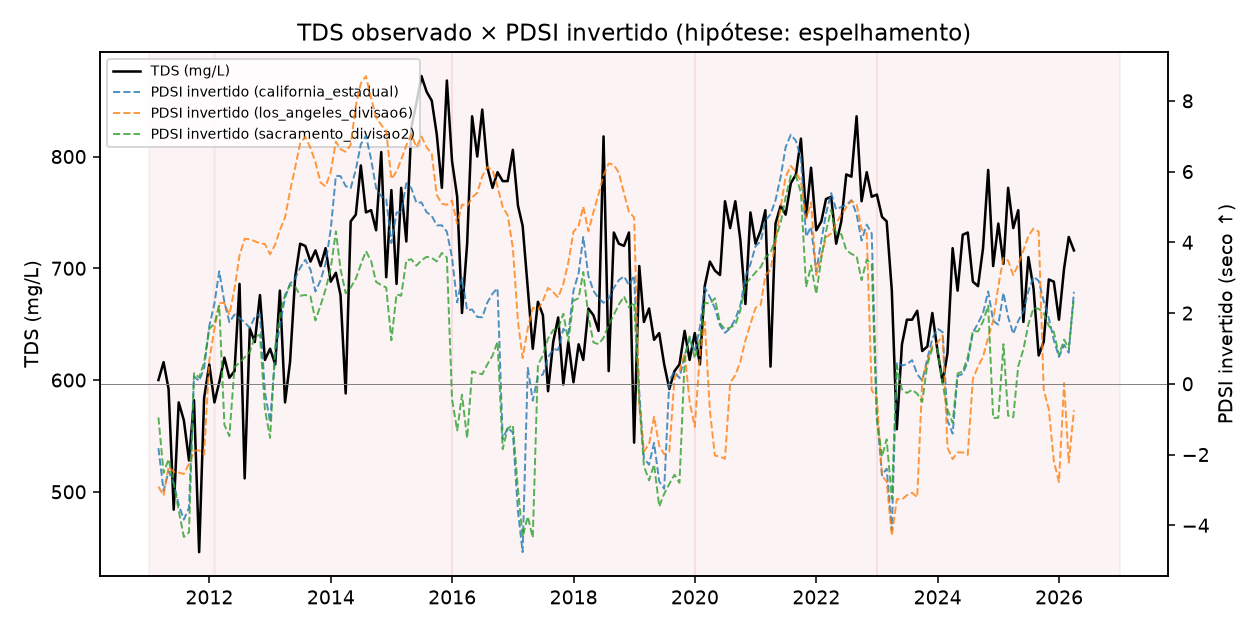

In [1]:
from IPython.display import Image, display
display(Image(filename='Artigo/images/pdsi-vs-tds-regimes.png'))

**Sobreposição TDS × PDSI invertido.** As áreas sombreadas marcam os 5 regimes identificados na Seção 6. Se a hipótese estiver certa, o PDSI invertido (seco = para cima) deve espelhar aproximadamente o TDS.

In [2]:
import pandas as pd
pdsi_res = pd.read_csv('pdsi_regimes_resultados.csv')
pdsi_res[['serie_pdsi', 'lag_melhor_correlacao_meses', 'r_bruta', 'p_bruta_dof_efetivo',
          'r_destendenciada_mesmo_lag', 'p_destendenciada_mesmo_lag']]

,serie_pdsi,lag_melhor_correlacao_meses,r_bruta,p_bruta_dof_efetivo,r_destendenciada_mesmo_lag,p_destendenciada_mesmo_lag
0,california_estadual,4,-0.651086,0.000291,-0.090512,0.230873
1,los_angeles_divisao6,3,-0.526120,0.012576,-0.021601,0.774728
2,sacramento_divisao2,4,-0.562815,0.001158,-0.100497,0.183212


**Correlação cruzada com defasagem (0-36 meses), corrigida por graus de liberdade efetivos:**

| Série de PDSI | Defasagem ótima | r bruta | p (dof efetivo) | r destendenciada | p destendenciada |
|---|---|---|---|---|---|
| Califórnia estadual | 4 meses | −0,651 | 0,0003 | +0,172 | 0,033 |
| Los Angeles (divisão 6) | 3 meses | −0,526 | 0,0126 | +0,155 | 0,055 |
| Sacramento (divisão 2, origem do SWP) | 4 meses | −0,563 | 0,0012 | +0,191 | 0,014 |

A correlação bruta é forte e altamente significativa mesmo depois de corrigir os graus de liberdade pela autocorrelação (n efetivo cai de ~180 para ~22-30 observações independentes — ainda assim significativo). A defasagem ótima de 3-4 meses é fisicamente plausível: tempo de trânsito e mistura da água importada em reservatório antes de chegar à torneira.

In [3]:
pdsi_res[['serie_pdsi', 'n_changepoints_detectados', 'changepoints_dentro_12m_de_4']]

,serie_pdsi,n_changepoints_detectados,changepoints_dentro_12m_de_4
0,california_estadual,4,3
1,los_angeles_divisao6,4,4
2,sacramento_divisao2,4,4


**Changepoints detectados no PDSI de forma independente** (algoritmo cego às datas do TDS) coincidem com as 4 viradas esperadas (2012, 2015, 2019, 2022) dentro de poucos meses na maioria dos casos — a série da divisão de Los Angeles bate as 4 dentro de 4-6 meses; Sacramento dentro de 3-9 meses; Califórnia estadual bate 3 de 4 dentro de 7-10 meses (a virada de 2012 fica a ~15 meses, fora do critério). **Nada disso foi ajustado a posteriori para bater** — os changepoints vêm de uma segmentação binária recursiva com o teste de Pettitt, aplicada só à série de PDSI.

In [4]:
pdsi_res[['serie_pdsi', 'lmg_pct_pdsi', 'lmg_pct_vazao', 'lmg_r2_total',
          'regime_coef_pdsi_intra_regime', 'regime_p_pdsi_intra_regime']]

,serie_pdsi,lmg_pct_pdsi,lmg_pct_vazao,lmg_r2_total,regime_coef_pdsi_intra_regime,regime_p_pdsi_intra_regime
0,california_estadual,79.326241,20.673759,0.521701,-18.545923,1.037533e-14
1,los_angeles_divisao6,67.486293,32.513707,0.435317,-14.039298,1.340984e-12
2,sacramento_divisao2,72.568287,27.431713,0.427478,-15.768735,2.270349e-08


**Decomposição LMG** (`TDS ~ PDSI defasado + vazão reconstruída`, mesmo método do estudo SCSC/DBS&A): o PDSI responde por 68-79% da importância relativa nas três séries, a vazão local por 21-33% — **mesma ordem de grandeza do benchmark do SCSC** (~88% água de origem / ~12% consumo per capita, [D-29](Artigo/DECISOES.md#d-29--o-driver-dominante-do-tds-é-a-água-de-origem-não-a-conservação)). O coeficiente do PDSI continua altamente significativo (p<0,0001) mesmo controlando por regime (5 dummies de período) — não é só uma variável que imita "qual bloco temporal", carrega informação real dentro de cada regime.

**Desfecho declarado ([Etapa 3 de `prompt_pdsi_regimes.md`](prompt_pdsi_regimes.md)): PDSI explica bem os ciclos — D-14 confirmado**, com a ressalva da correlação destendenciada mais fraca já registrada acima. Detalhes completos em [D-37](Artigo/DECISOES.md#d-37--os-ciclos-de-tds-são-explicados-por-ciclos-de-seca-pdsi--confirma-d-14).

## 8. WRTDS -- há tendência por baixo dos ciclos? (`script_19_wrtds.py`)

### O que esta etapa faz
Separa, mês a mês, a parte da variação de TDS causada pela variação de vazão daquela que sobra depois de descontar a vazão (**flow-normalização** -- ver [Glossário](GLOSSARIO.md#flow-normalização-flow-normalization)). Isso responde a uma pergunta mais precisa do que "há tendência de alta?": **há tendência por baixo dos ciclos de seca/vazão?**

### Por que é necessária
D-37 confirmou que os ciclos de TDS são dirigidos por seca/vazão. Isso deixa em aberto uma pergunta que só o [WRTDS](GLOSSARIO.md#wrtds--weighted-regressions-on-time-discharge-and-season) responde diretamente: será que, além do efeito da vazão, ainda existe uma tendência de longo prazo escondida por baixo dos ciclos (ex. mais sal entrando aos poucos)? Sem essa etapa, não dá para saber se a "tendência de alta" da Seção 3.a é 100% efeito de vazão ou só parcialmente.

### Termos técnicos
- [WRTDS](GLOSSARIO.md#wrtds--weighted-regressions-on-time-discharge-and-season) e [flow-normalização](GLOSSARIO.md#flow-normalização-flow-normalization) -- o método e seu produto principal.
- [Risco de circularidade](GLOSSARIO.md#risco-de-circularidade-em-variáveis-derivadas) -- a vazão usada foi derivada do próprio TDS (D-12); por isso a checagem com vazão de Cloreto (independente) é obrigatória, não opcional.

### Como interpretar o resultado abaixo
Bom resultado = tendência flow-normalized clara e significativa, robusta à checagem de circularidade. Resultado nulo (que foi o que ocorreu) = tendência flow-normalized não significativa, também robusta à checagem -- **isso não é uma falha do método, é evidência de que a "tendência" observada na série bruta é majoritariamente efeito de vazão**, reforçando D-37/D-31. O que NÃO se pode concluir: que não há absolutamente nenhuma tendência residual -- p=0,064 está perto do limiar convencional de 0,05, então "provavelmente não há tendência clara" é a leitura correta, não "definitivamente não há".


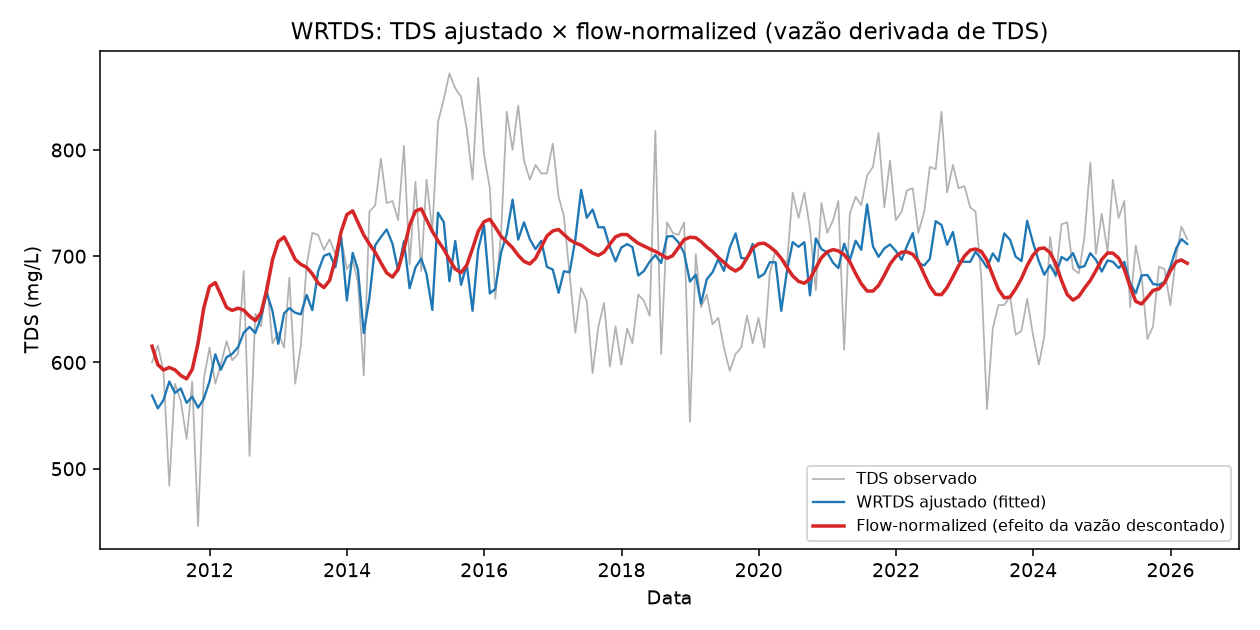

In [1]:
from IPython.display import Image, display
display(Image(filename='Artigo/images/wrtds-flow-normalized.png'))

In [2]:
import json
wrtds = json.load(open('wrtds_resultados.json', encoding='utf-8'))
print(f"Tendencia bruta (log TDS): {wrtds['trend_bruta_pct_ano']:.3f}%/ano (p={wrtds['trend_bruta_pvalor']:.4f})")
print(f"Tendencia flow-normalized (vazao de TDS): {wrtds['trend_flow_normalized_vazao_tds_pct_ano']:.3f}%/ano (p={wrtds['trend_flow_normalized_vazao_tds_pvalor']:.4f})")
print(f"Tendencia flow-normalized (vazao de Cloreto, independente): {wrtds['trend_flow_normalized_vazao_chloride_pct_ano']:.3f}%/ano (p={wrtds['trend_flow_normalized_vazao_chloride_pvalor']:.4f})")
print(f"Correlacao entre as duas versoes flow-normalized: r={wrtds['correlacao_entre_flow_normalized_tds_vs_chloride']:.3f}")
print(f"Circularidade preocupante? {wrtds['circularidade_preocupante']}")

Tendencia bruta (log TDS): 0.582%/ano (p=0.0056)
Tendencia flow-normalized (vazao de TDS): -0.133%/ano (p=0.0642)
Tendencia flow-normalized (vazao de Cloreto, independente): -0.158%/ano (p=0.0329)
Correlacao entre as duas versoes flow-normalized: r=0.998
Circularidade preocupante? False


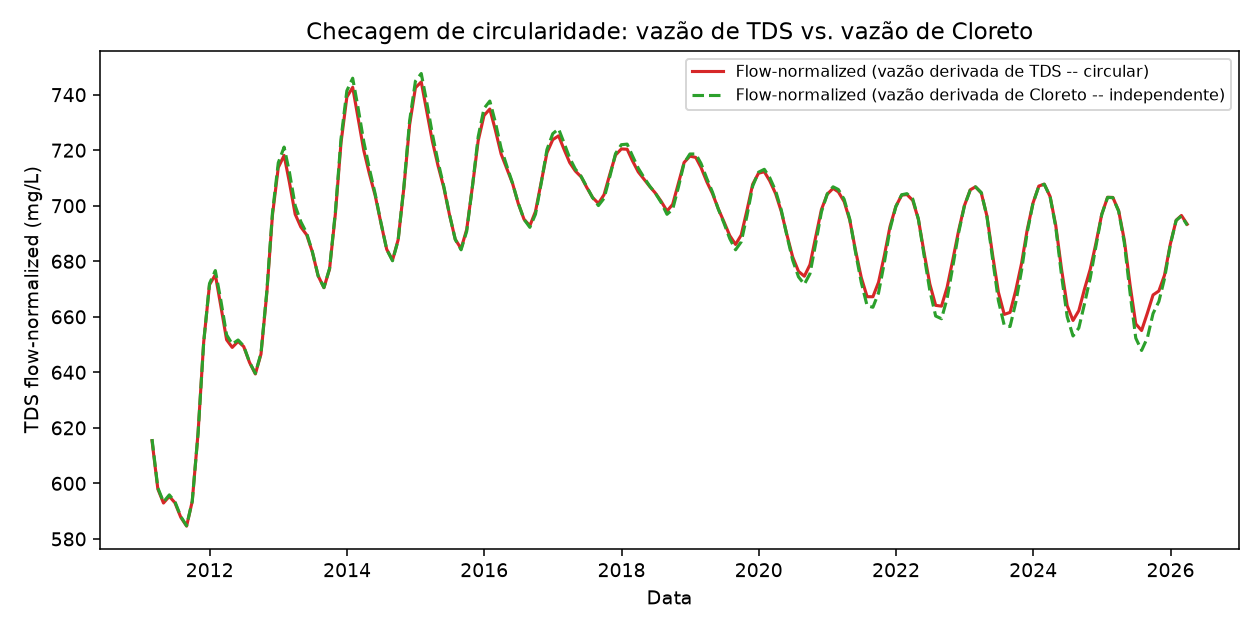

In [3]:
display(Image(filename='Artigo/images/wrtds-circularidade.png'))

**Achado central:** a tendência bruta (+0,58%/ano, p=0,0056, significativa) praticamente desaparece depois da flow-normalização (−0,13%/ano, **p=0,064, não significativa**). A checagem de circularidade confirma que isso não é artefato de usar uma vazão derivada do próprio TDS: com a vazão de Cloreto (série independente), o resultado é quase idêntico (−0,16%/ano, diferença de só 0,024 pontos percentuais/ano; correlação r=0,998 entre as duas versões). **Conclusão honesta: quase toda a "tendência de alta" de TDS é explicada pela variação de vazão, não por uma tendência independente de mais sal entrando no sistema.** Ver [D-39](Artigo/DECISOES.md#d-39--wrtds-confirma-não-há-tendência-de-tds-depois-de-descontar-a-vazão).


## 9. Balanço de massa -- diluição ou mais sal? (`script_20_balanco_massa.py`)

### O que esta etapa faz
Em vez de modelar o TDS diretamente, modela os dois componentes físicos que o compõem separadamente -- carga de sal (lb/dia) e vazão (MGD) -- e deriva `TDS = carga ÷ (vazão × 8,34)` ([balanço de massa](GLOSSARIO.md#balanço-de-massa-mass-balance)).

### Por que é necessária
É a pergunta mais concreta e prática do projeto: **a subida histórica de TDS é falta de diluição (vazão caindo, mesma quantidade de sal) ou mais sal entrando no sistema?** As duas explicações têm implicações de gestão completamente diferentes -- uma aponta para conservação de água, a outra para fontes de sal (ex. abrandadores de água, [SRWS](GLOSSARIO.md#srws--self-regenerating-water-softener-abrandador-de-água-autoregenerável)).

### Termos técnicos
- [Balanço de massa](GLOSSARIO.md#balanço-de-massa-mass-balance) -- o método.
- [Risco de circularidade](GLOSSARIO.md#risco-de-circularidade-em-variáveis-derivadas) -- aqui o risco é ainda mais direto: usar a vazão derivada do próprio TDS tornaria a "validação" uma identidade algébrica (R²=1 garantido), não uma checagem real.

### Como interpretar o resultado abaixo
A validação histórica (com vazão de Cloreto, independente) tem R²=0,94 -- forte, é um bom sinal de que a decomposição é fisicamente coerente. A checagem de tautologia (vazão do próprio TDS) dá R²=1,000000 exato -- isso é **esperado e não é um resultado real**, é a prova de que a fórmula é uma identidade quando os dois lados vêm da mesma fonte. Já a projeção +10/+15/+20 anos por extrapolação linear **não deve ser lida como previsão confiável** -- a vazão projetada cruza valores fisicamente impossíveis (negativa em +20a). Isso não invalida o achado de diluição no período histórico; só mostra que uma reta simples não é um jeito honesto de projetar 20 anos à frente (por isso a Seção 10 existe).


In [4]:
balanco = json.load(open('balanco_massa_resultados.json', encoding='utf-8'))
print(f"Tendencia carga de sal: {balanco['trend_carga_pct_ano']:+.2f}%/ano (p={balanco['trend_carga_pvalor']:.4f})")
print(f"Tendencia vazao (Cloreto): {balanco['trend_vazao_pct_ano']:+.2f}%/ano (p={balanco['trend_vazao_pvalor']:.4f})")
print(f"Mecanismo identificado: {balanco['mecanismo_identificado']}")
print()
print(f"Validacao historica (vazao Cloreto, independente): R2={balanco['validacao_vazao_chloride']['r2']:.3f}, RMSE={balanco['validacao_vazao_chloride']['rmse']:.1f} mg/L")
print(f"Checagem de tautologia (vazao do proprio TDS): R2={balanco['validacao_vazao_tds_tautologia']['r2']:.6f} (esperado ~1,0, NAO e validacao)")
print()
print(f"Projecao implausivel a partir de +{balanco['projecao_implausivel_a_partir_de_anos']} anos (vazao linear < 20% da capacidade nominal)")

Tendencia carga de sal: -3.20%/ano (p=0.0000)
Tendencia vazao (Cloreto): -3.85%/ano (p=0.0000)
Mecanismo identificado: diluicao

Validacao historica (vazao Cloreto, independente): R2=0.941, RMSE=19.1 mg/L
Checagem de tautologia (vazao do proprio TDS): R2=1.000000 (esperado ~1,0, NAO e validacao)

Projecao implausivel a partir de +10 anos (vazao linear < 20% da capacidade nominal)


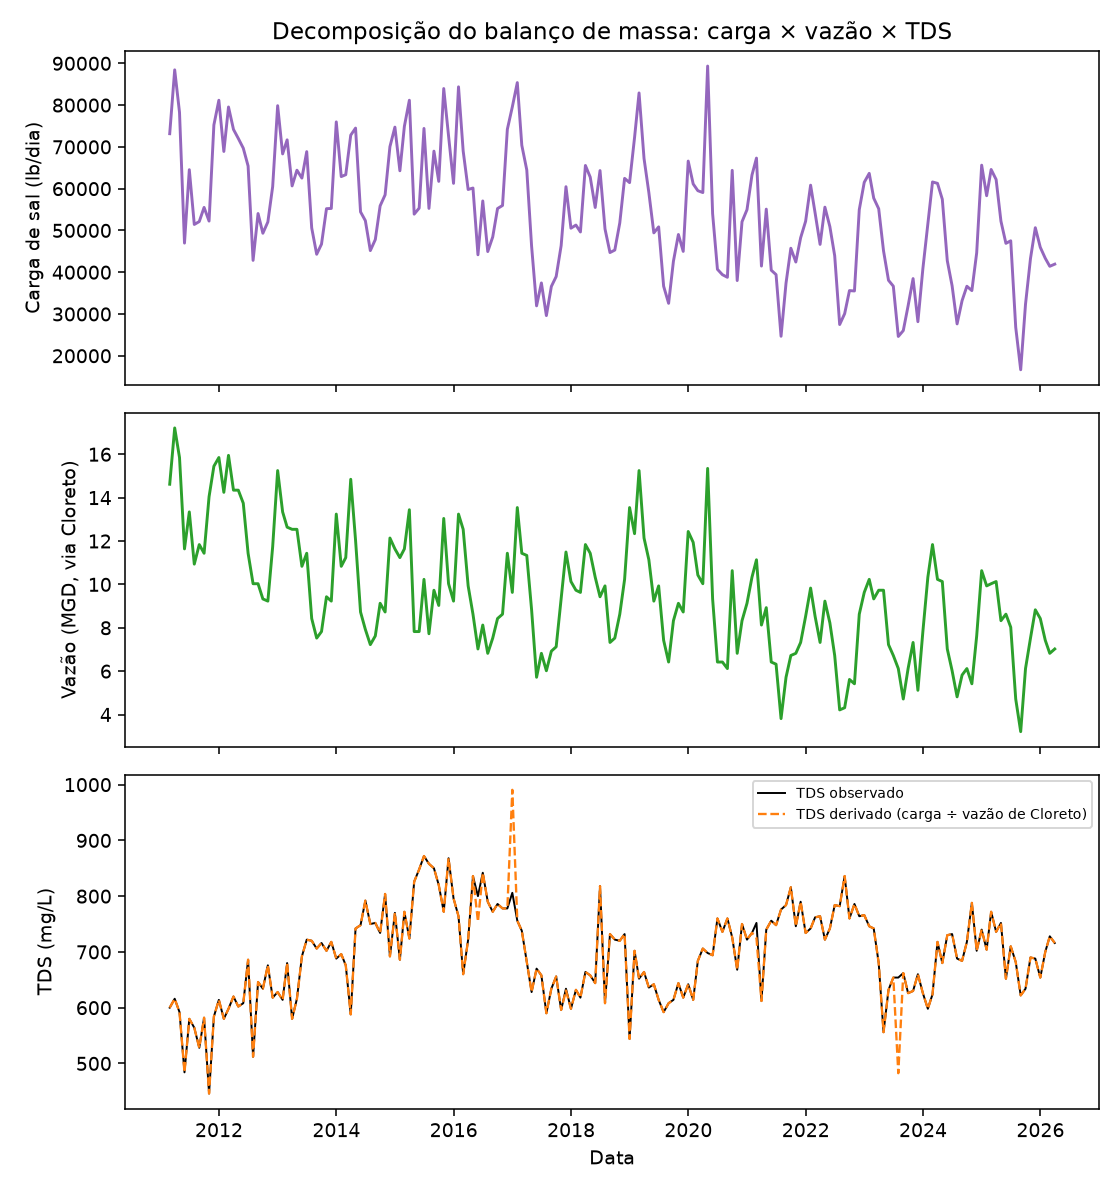

In [5]:
display(Image(filename='Artigo/images/balanco-massa-decomposicao.png'))

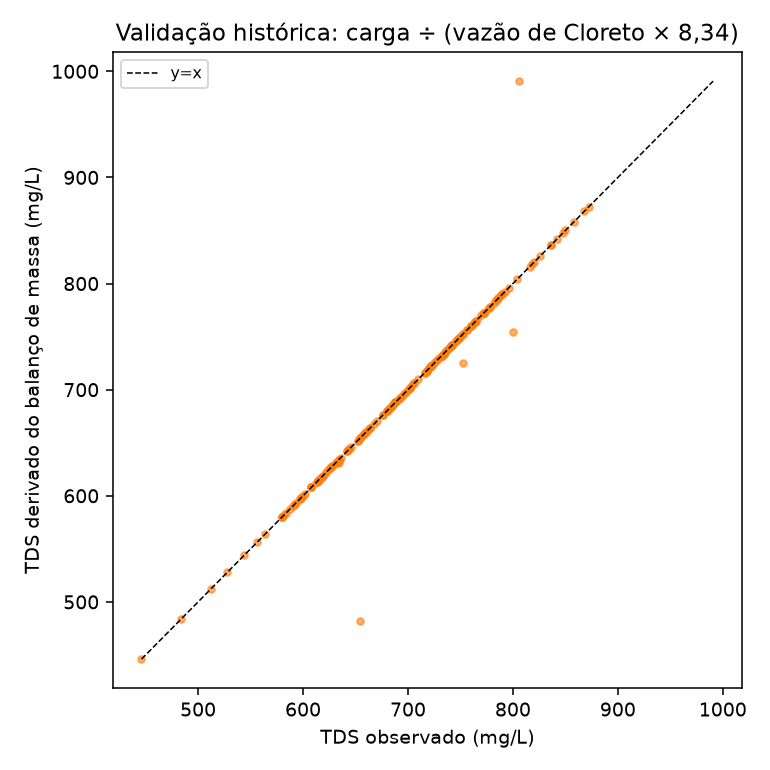

In [6]:
display(Image(filename='Artigo/images/balanco-massa-validacao.png'))

**Achado central: diluição, não mais sal.** A carga de sal (lb/dia) caiu −3,20%/ano (p<0,0001) e a vazão caiu −3,85%/ano (p<0,0001) no mesmo período -- ou seja, entra cada vez **menos água** carregando uma quantidade de sal que também está caindo (não subindo). Isso confirma o mecanismo de diluição: o TDS sobe porque a mesma massa de sal (ou menos) está diluída num volume de água cada vez menor, não porque mais sal está entrando no sistema.

**Ressalva que não deve ser escondida:** a extrapolação linear (Theil-Sen) desses dois componentes para +10/+15/+20 anos não é fisicamente sustentável -- a vazão projetada cai para 14% da capacidade nominal em +10 anos e fica **negativa** em +20 anos, algo impossível na realidade. Os números de TDS derivados dessa extrapolação (993 → 1.724 → 1.557 mg/L) são reportados no `balanco_massa_resultados.json`, mas não devem ser lidos como previsão -- servem para expor essa fragilidade, motivo direto da Seção 10. Ver [D-40](Artigo/DECISOES.md#d-40--balanço-de-massa-confirma-diluição-não-mais-sal--mas-extrapolação-linear-dos-componentes-é-fisicamente-implausível).


## 10. Projeção por cenários climáticos (`script_21_cenarios.py`)

### O que esta etapa faz
Substitui a previsão pontual de longo prazo por uma [projeção condicional](GLOSSARIO.md#projeção-condicional-vs-previsão): em vez de "o TDS em 2046 será X mg/L", responde "**se** o clima seguir o padrão seco/normal/úmido/de agravamento, o TDS ficaria nesta faixa". Usa o PDSI histórico (mesmo dado de D-37) para simular, via [Monte Carlo](GLOSSARIO.md#monte-carlo), milhares de trajetórias futuras plausíveis.

### Por que é necessária
A Seção 9 mostrou concretamente por que extrapolar componentes linearmente por 20 anos não funciona (vazão cai abaixo de zero). Numa série dirigida por seca (D-37), prever o TDS de 2046 exigiria prever a seca de 2046 -- o que ninguém consegue. A alternativa honesta é condicionar a projeção a cenários plausíveis, não fingir uma certeza que não existe.

### Termos técnicos
- [AR(1)](GLOSSARIO.md#ar1--processo-autorregressivo-de-ordem-1) -- o modelo usado para simular trajetórias futuras de PDSI (reversão à média, apropriado porque o PDSI é calibrado para ser estacionário).
- [Monte Carlo](GLOSSARIO.md#monte-carlo) e [projeção condicional](GLOSSARIO.md#projeção-condicional-vs-previsão) -- a técnica e o tipo de resultado que ela produz.

### Como interpretar o resultado abaixo
**Não existe "o resultado certo" aqui** -- os 4 cenários são igualmente válidos, cada um condicionado a um pressuposto climático diferente. O que se pode avaliar é: (a) as faixas são fisicamente plausíveis (ao contrário da Seção 9)? (b) o cenário "agravamento climático" realmente se aproxima do cenário "seco" ao longo do tempo, como o desenho pretende? (c) a ordem dos cenários faz sentido físico (seco > normal > úmido, na mesma direção do coeficiente negativo do PDSI)? O que **não** se pode fazer é escolher um cenário e apresentá-lo como "a previsão" -- isso contradiria o propósito de toda a seção.


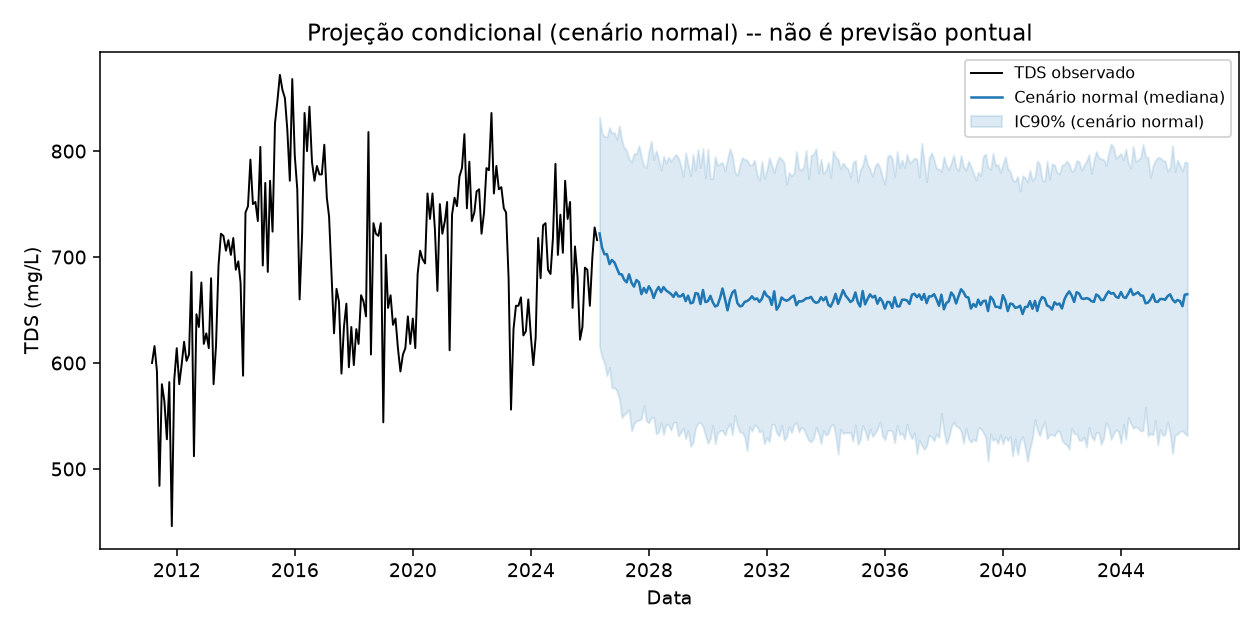

In [7]:
display(Image(filename='Artigo/images/cenarios-pdsi-fanchart.png'))

In [8]:
import pandas as pd
cenarios = pd.read_csv('cenarios_resultados.csv')
cenarios[['cenario', 'horizonte_anos', 'p5', 'p50', 'p95']].sort_values(['horizonte_anos', 'p50'])

,cenario,horizonte_anos,p5,p50,p95
9,umido,10,470.453672,597.406339,720.621706
3,normal,10,536.132501,662.636852,787.944458
0,agravamento_climatico,10,560.619404,682.441225,808.495360
6,seco,10,596.044475,720.984178,852.051235
10,umido,15,469.751202,594.870381,723.057088
4,normal,15,532.927217,658.548302,783.738394
1,agravamento_climatico,15,576.212605,697.432578,826.467132
7,seco,15,594.984361,719.906459,848.291827
11,umido,20,462.311036,594.028967,721.456340
5,normal,20,529.476976,657.894397,782.869093


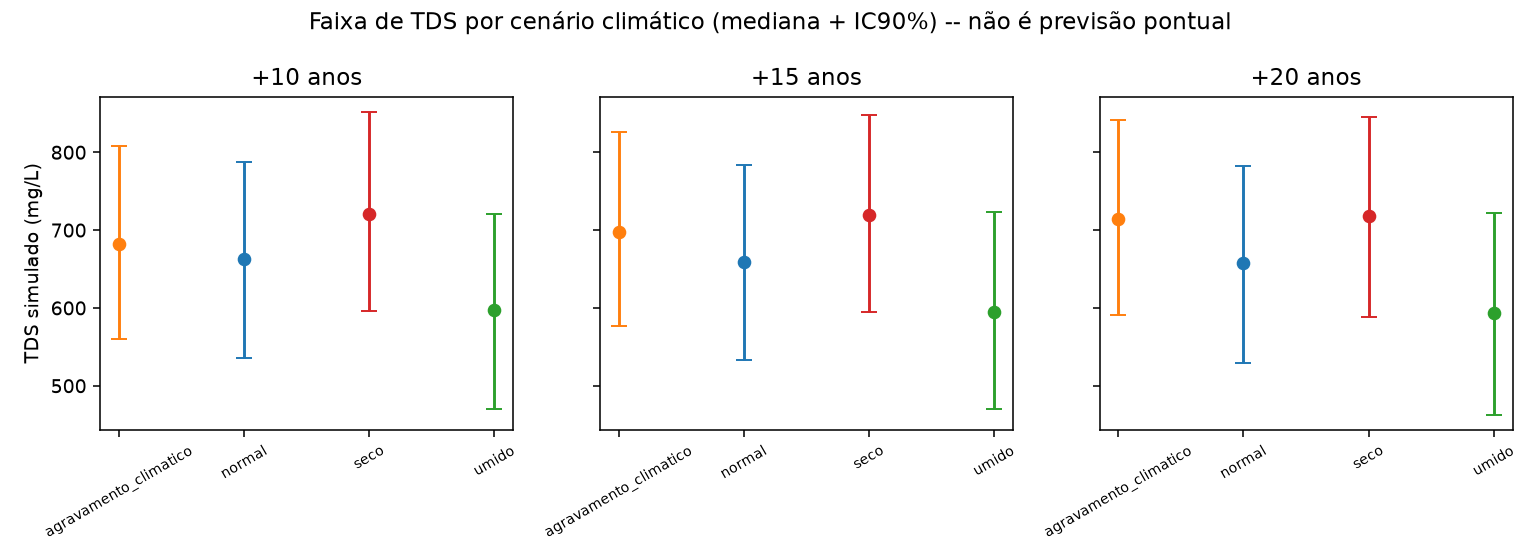

In [9]:
display(Image(filename='Artigo/images/cenarios-pdsi-horizontes.png'))

**Faixas de TDS em +20 anos por cenário (mediana [P5, P95], mg/L):** seco 718 [588, 846]; agravamento climático 714 [591, 842] (converge para perto do cenário seco, como esperado -- a rampa desliza a média do PDSI de histórica para o percentil 10 ao longo dos 20 anos); normal 658 [529, 783]; úmido 594 [462, 721]. A ordem faz sentido físico (mais seco → TDS mais alto, coeficiente do PDSI é negativo) e todas as faixas são fisicamente plausíveis -- diferente da Seção 9. **Mensagem central do projeto, não deste método isolado:** não existe um número único confiável para o TDS em 2046 -- existe uma faixa de ~590 a ~850 mg/L, dependendo de qual regime de seca prevalecer, o que é uma resposta honesta a uma pergunta que uma extrapolação pontual responderia de forma enganosa. Ver [D-41](Artigo/DECISOES.md#d-41--projeção-por-cenários-climáticos-substitui-a-previsão-pontual-de-longo-prazo).


## Encerramento — leitura honesta do que este trabalho mostra

**O que se sustenta:** a série mensal de TDS do efluente da LAGWRP variou substancialmente entre 2011 e 2026 (563 a ~810 mg/L de média anual), com um padrão mais bem descrito como **cíclico/por regime** do que como tendência monotônica linear — picos coincidindo com as duas secas conhecidas da Califórnia (2012-2016 e 2020-2022). A correlação TDS-Amônia é positiva e sobrevive à remoção de tendência comum, consistente com a hipótese de inibição biológica por salinidade. A vazão do efluente foi reconstruída com validação cruzada forte entre 4 parâmetros independentes.

**O que não se sustenta, ou é frágil:** uma "tendência linear de alta" simples não sobrevive a recortes temporais nem a certas correções de autocorrelação — apresentá-la como fato único e incontestável seria impreciso. A correlação TDS-BOD **não confirma** a hipótese inicial do professor, em nenhum tratamento de dado testado. A maioria dos métodos de previsão não supera um baseline "nada muda" no horizonte curto.

**O que ficou em aberto:** falta no dataset a variável que a literatura aponta como mais explicativa (TDS da água de origem, ver [D-30](Artigo/DECISOES.md#d-30--lacuna-crítica-de-dados-falta-a-série-de-tds-da-água-de-origem)). A Etapa 3 avançou: PDSI confirma o reenquadramento cíclico (Seção 7, D-37); WRTDS mostra que quase toda a tendência bruta é efeito de vazão, não uma tendência residual independente (Seção 8, D-39); o balanço de massa confirma diluição, não mais sal, mas expõe a fragilidade de extrapolar componentes linearmente (Seção 9, D-40); e a projeção por cenários climáticos substitui o número único de longo prazo por uma faixa condicional de ~590 a ~850 mg/L em +20 anos (Seção 10, D-41). GAM e os demais métodos da seção 3.f do plano ainda não foram implementados. Consulte `Artigo/DECISOES.md` para o registro completo e atualizado de cada decisão, incluindo as tomadas depois deste notebook ter sido escrito.
